In [1]:
########################################
# Packages
########################################
import warnings
import h5py as h5
import numpy as np
import pandas as pd
import multiprocessing as mp

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import math

import statistics

from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import binned_statistic
import scipy.stats.distributions as dist

import seaborn as sns

In [2]:
# Meagan (z=0)
from data_processing import SHARKDataProcessor
processor = SHARKDataProcessor()

# Define subvolume IDs and HDF5 file paths
sv_list = np.arange(64)

sharkfiles = [f'moxland_extracted/Shark_v2_moxland_L23_HBT_PSO_default/201/{sv}/galaxies.hdf5' for sv in sv_list]

# Output shark_csv dataframe
shark_csv = processor.process_all_subvolumes(sv_list, sharkfiles)
print(shark_csv.head())

  ID_galaxy ID_subhalo    ID_subhalo_tree ID_halo  sv  type    Mhalo_host  \
0       0_0        0_1  0_201000000000002     0_1   0     0  4.615949e+13   
1   0_13293        0_2  0_201000001068281     0_1   0     1  4.615949e+13   
2    0_2489        0_3  0_201000000190829     0_1   0     1  4.615949e+13   
3   0_14426        0_4  0_201000001162466     0_1   0     1  4.615949e+13   
4   0_32551        0_5  0_201000002709050     0_1   0     1  4.615949e+13   

          Mhalo   Mstar_bulge    Mstar_disc  ...  SFR_bulge  SFR_disc  \
0  4.354074e+13  3.102665e+11  1.649109e+11  ...   0.018547  0.277604   
1  1.338565e+12  2.474200e+08  2.926713e+10  ...   0.000000  1.211307   
2  1.554335e+11  1.877154e+10  1.104441e+10  ...   0.000011  0.397177   
3  1.213300e+11  2.487775e+09  5.267482e+07  ...   0.000159  0.112389   
4  1.026386e+11  6.757129e+06  2.448743e+08  ...   0.000000  0.000000   

    SFR_all           MBH   MBHacc_cold    MBHacc_hot    MBHacc_all  \
0  0.296151  1.717095e+09  

In [3]:
# Meagan (z=0.5)
from data_processing import SHARKDataProcessor
processor = SHARKDataProcessor()

# Define subvolume IDs and HDF5 file paths
sv_list = np.arange(64)
sharkfiles = [f'moxland_extracted/Shark_v2_moxland_L23_HBT_PSO_default/177/{sv}/galaxies.hdf5' for sv in sv_list]

# Output shark_csv dataframe
shark_csv_z05 = processor.process_all_subvolumes(sv_list, sharkfiles)
print(shark_csv_z05.head())
#print(shark_csv.shape)

  ID_galaxy ID_subhalo    ID_subhalo_tree ID_halo  sv  type    Mhalo_host  \
0       0_0        0_1  0_177000000000002     0_1   0     0  4.344694e+13   
1   0_40747        0_1  0_177000000000002     0_1   0     2  4.344694e+13   
2   0_24862        0_1  0_177000000000002     0_1   0     2  4.344694e+13   
3    0_4860        0_2  0_177000000220938     0_1   0     1  4.344694e+13   
4    0_2489        0_3  0_177000000190829     0_1   0     1  4.344694e+13   

          Mhalo   Mstar_bulge    Mstar_disc  ...  SFR_bulge  SFR_disc  \
0  4.019334e+13  2.079636e+11  1.633882e+11  ...   0.097798  1.148811   
1  2.033097e+10  4.163854e+03  1.218719e+09  ...   0.000000  0.050183   
2  3.508732e+10  2.555240e+07  5.073121e+08  ...   0.000000  0.000000   
3  1.299215e+12  8.555392e+10  1.200620e+09  ...   0.178918  0.805716   
4  4.863037e+11  1.877117e+10  7.814867e+09  ...   0.000652  2.898656   

    SFR_all           MBH  MBHacc_cold    MBHacc_hot  MBHacc_all  \
0  1.246608  1.518675e+09     

In [4]:
# Meagan (z=1)
from data_processing import SHARKDataProcessor
processor = SHARKDataProcessor()

# Define subvolume IDs and HDF5 file paths
sv_list = np.arange(64)
sharkfiles = [f'moxland_extracted/Shark_v2_moxland_L23_HBT_PSO_default/161/{sv}/galaxies.hdf5' for sv in sv_list]

# Output shark_csv dataframe
shark_csv_z1 = processor.process_all_subvolumes(sv_list, sharkfiles)
print(shark_csv_z1.head())
#print(shark_csv.shape)

  ID_galaxy ID_subhalo    ID_subhalo_tree ID_halo  sv  type    Mhalo_host  \
0       0_0        0_1  0_161000000000002     0_1   0     0  3.804515e+13   
1    0_7595        0_1  0_161000000000002     0_1   0     2  3.804515e+13   
2     0_761        0_2  0_161000000058343     0_1   0     1  3.804515e+13   
3    0_1337        0_3  0_161000000100261     0_1   0     1  3.804515e+13   
4   0_24863        0_4  0_161000001815267     0_1   0     1  3.804515e+13   

          Mhalo   Mstar_bulge    Mstar_disc  ...  SFR_bulge   SFR_disc  \
0  3.632095e+13  1.403548e+11  1.616429e+11  ...   0.548854   1.027707   
1  1.016548e+10  1.308828e+07  4.926251e+08  ...   0.000000   0.001725   
2  2.485625e+11  1.996549e+10  2.358676e+10  ...   0.001695  20.459056   
3  1.744528e+11  1.047300e+10  2.856429e+09  ...   0.000246   1.027863   
4  1.524823e+11  6.812143e+06  8.669310e+08  ...   0.000000   0.048453   

     SFR_all           MBH  MBHacc_cold    MBHacc_hot    MBHacc_all  \
0   1.576560  1.38822

In [5]:
# LAGOS 24
from data_processing import SHARKDataProcessor
processor = SHARKDataProcessor()

# Define subvolume IDs and HDF5 file paths
sv_list = np.arange(64)
sharkfiles_lagos = [f'extracted_data_z=0/199/{sv}/galaxies.hdf5' for sv in sv_list] #DEFINE FILE

# Output shark_csv dataframe
shark_csv_lagos = processor.process_all_subvolumes(sv_list, sharkfiles_lagos)
print(shark_csv_lagos.head())

  ID_galaxy ID_subhalo    ID_subhalo_tree ID_halo  sv  type    Mhalo_host  \
0   0_12323        0_1  0_199000000000184     0_1   0     0  1.553645e+12   
1   0_41884        0_2  0_199000000032613     0_1   0     1  1.553645e+12   
2   0_25337        0_4  0_199000000000239     0_2   0     0  1.013176e+12   
3   0_12324        0_4  0_199000000000239     0_2   0     2  1.013176e+12   
4  0_325815        0_5  0_199000000032723     0_2   0     1  1.013176e+12   

          Mhalo   Mstar_bulge    Mstar_disc  ...  SFR_bulge  SFR_disc  \
0  1.406334e+12  4.406725e+10  8.090279e+09  ...   0.239161  8.448190   
1  1.132662e+11  6.663850e+07  3.927870e+08  ...   0.000000  0.045958   
2  7.889350e+11  1.441911e+10  7.342129e+06  ...   5.469577  0.054259   
3  4.321138e+10  4.237961e+08  9.966004e+08  ...   0.000000  0.128186   
4  2.242409e+11  4.860634e+08  7.437644e+08  ...   0.000000  0.316807   

    SFR_all           MBH  MBHacc_cold    MBHacc_hot    MBHacc_all  \
0  8.687351  2.992633e+07   

In [6]:
# CHANDRO GOMEZ z=0
########################################
# Halo Mass HIST
########################################

# Calling halo mass values and eliminating ones less than 0
HaloM_fig1 = shark_csv['Mhalo_host']
HaloM_fig1 = HaloM_fig1[HaloM_fig1 > 0]

########################################
# Halo Mass KDE
########################################

# Log-transform halo mass values for KDE
HaloM_fig1_log = np.log10(HaloM_fig1)

# Create KDE based on log-transformed values
KDEtest_fig1 = gaussian_kde(HaloM_fig1_log)

# Generate x values for KDE in log space and evaluate KDE
KDE_xvals_fig1 = np.linspace(min(HaloM_fig1_log), max(HaloM_fig1_log), 200)
KDE_yvals_fig1 = KDEtest_fig1(KDE_xvals_fig1)

########################################
# Stellar Mass HIST
########################################

# Calling stellar mass values and eliminating ones less than 0
StellarM_fig2 = shark_csv['Mstar_all']
StellarM_fig2 = StellarM_fig2[StellarM_fig2 > 0]

########################################
# Stellar Mass KDE
########################################

# Log-transform stellar mass values for KDE
StellarM_fig2_log = np.log10(StellarM_fig2)

# Create KDE based on log-transformed values
KDEtest_fig2 = gaussian_kde(StellarM_fig2_log)

# Generate x values for KDE in log space and evaluate KDE
KDE_xvals_fig2 = np.linspace(min(StellarM_fig2_log), max(StellarM_fig2_log), 200)
KDE_yvals_fig2 = KDEtest_fig2(KDE_xvals_fig2)

########################################
# SSFR (Histogram + KDE)
########################################
SSFR = shark_csv['SFR_all'] / shark_csv['Mstar_all']
# Calling halo mass values and eliminating ones less than 0
SSFR = SSFR[SSFR > 0]
SSFR = np.where(SSFR < 1e-14, 1e-14, SSFR)

########################################
# SSFR KDE
########################################

# Log-transform halo mass values for KDE
SSFR_fig3_log = np.log10(SSFR)

# Create KDE based on log-transformed values
SSFR_KDEtest_fig3 = gaussian_kde(SSFR_fig3_log)

# Generate x values for KDE in log space and evaluate KDE
SSFR_KDE_xvals_fig3 = np.linspace(min(SSFR_fig3_log), max(SSFR_fig3_log), 200)
SSFR_KDE_yvals_fig3 = SSFR_KDEtest_fig3(SSFR_KDE_xvals_fig3)

In [7]:
# Set bin widths

bins_fig1 = np.linspace(np.min(HaloM_fig1_log), np.max(HaloM_fig1_log), 25)

bins_fig2 = np.linspace(np.min(StellarM_fig2_log), np.max(StellarM_fig2_log), 25)

bins_fig3 = np.linspace(np.min(SSFR_fig3_log), np.max(SSFR_fig3_log), 25)

#plt.hist(StellarM_fig2_log, density=True, bins=bins_fig2)

#plt.hist(SSFR_fig3_log, density=True, bins=bins_fig3)

In [8]:
# CHANDRO GOMEZ z=0.5
########################################
# Halo Mass (Histogram + KDE)
########################################

# Calling halo mass values and eliminating ones less than 0
HaloM_fig1_z05 = shark_csv_z05['Mhalo_host']
HaloM_fig1_z05 = HaloM_fig1_z05[HaloM_fig1_z05 > 0]

########################################
# KDE
########################################

# Log-transform halo mass values for KDE
HaloM_fig1_log_z05 = np.log10(HaloM_fig1_z05)

# Create KDE based on log-transformed values
KDEtest_fig1_z05 = gaussian_kde(HaloM_fig1_log_z05)

# Generate x values for KDE in log space and evaluate KDE
KDE_xvals_fig1_z05 = np.linspace(min(HaloM_fig1_log_z05), max(HaloM_fig1_log_z05), 200)
KDE_yvals_fig1_z05 = KDEtest_fig1_z05(KDE_xvals_fig1_z05)

########################################
# Stellar Mass HIST
########################################

# Calling stellar mass values and eliminating ones less than 0
StellarM_fig2_z05 = shark_csv_z05['Mstar_all']
StellarM_fig2_z05 = StellarM_fig2_z05[StellarM_fig2_z05 > 0]

########################################
# Stellar Mass KDE
########################################

# Log-transform stellar mass values for KDE
StellarM_fig2_log_z05 = np.log10(StellarM_fig2_z05)

# Create KDE based on log-transformed values
KDEtest_fig2_z05 = gaussian_kde(StellarM_fig2_log_z05)

# Generate x values for KDE in log space and evaluate KDE
KDE_xvals_fig2_z05 = np.linspace(min(StellarM_fig2_log_z05), max(StellarM_fig2_log_z05), 200)
KDE_yvals_fig2_z05 = KDEtest_fig2_z05(KDE_xvals_fig2_z05)

########################################
# SSFR (Histogram + KDE)
########################################
SSFR_z05 = shark_csv_z05['SFR_all'] / shark_csv_z05['Mstar_all']
# Calling halo mass values and eliminating ones less than 0
SSFR_z05 = SSFR_z05[SSFR_z05 > 0]
SSFR_z05 = np.where(SSFR_z05 < 1e-14, 1e-14, SSFR_z05)

########################################
# SSFR KDE
########################################

# Log-transform halo mass values for KDE
SSFR_fig3_log_z05 = np.log10(SSFR_z05)

# Create KDE based on log-transformed values
SSFR_KDEtest_fig3_z05 = gaussian_kde(SSFR_fig3_log_z05)

# Generate x values for KDE in log space and evaluate KDE
SSFR_KDE_xvals_fig3_z05 = np.linspace(min(SSFR_fig3_log_z05), max(SSFR_fig3_log_z05), 200)
SSFR_KDE_yvals_fig3_z05 = SSFR_KDEtest_fig3_z05(SSFR_KDE_xvals_fig3_z05)

In [9]:
# CHANDRO GOMEZ z=1
########################################
# Halo Mass (Histogram + KDE)
########################################

# Calling halo mass values and eliminating ones less than 0
HaloM_fig1_z1 = shark_csv_z1['Mhalo_host']
HaloM_fig1_z1 = HaloM_fig1_z1[HaloM_fig1_z1 > 0]

########################################
# KDE
########################################

# Log-transform halo mass values for KDE
HaloM_fig1_log_z1 = np.log10(HaloM_fig1_z1)

# Create KDE based on log-transformed values
KDEtest_fig1_z1 = gaussian_kde(HaloM_fig1_log_z1)

# Generate x values for KDE in log space and evaluate KDE
KDE_xvals_fig1_z1 = np.linspace(min(HaloM_fig1_log_z1), max(HaloM_fig1_log_z1), 200)
KDE_yvals_fig1_z1 = KDEtest_fig1_z1(KDE_xvals_fig1_z1)

########################################
# Stellar Mass HIST
########################################

# Calling stellar mass values and eliminating ones less than 0
StellarM_fig2_z1 = shark_csv_z1['Mstar_all']
StellarM_fig2_z1 = StellarM_fig2_z1[StellarM_fig2_z1 > 0]

########################################
# Stellar Mass KDE
########################################

# Log-transform stellar mass values for KDE
StellarM_fig2_log_z1 = np.log10(StellarM_fig2_z1)

# Create KDE based on log-transformed values
KDEtest_fig2_z1 = gaussian_kde(StellarM_fig2_log_z1)

# Generate x values for KDE in log space and evaluate KDE
KDE_xvals_fig2_z1 = np.linspace(min(StellarM_fig2_log_z1), max(StellarM_fig2_log_z1), 200)
KDE_yvals_fig2_z1 = KDEtest_fig2_z1(KDE_xvals_fig2_z1)

########################################
# SSFR (Histogram + KDE)
########################################
SSFR_z1 = shark_csv_z1['SFR_all'] / shark_csv_z1['Mstar_all']
# Calling halo mass values and eliminating ones less than 0
SSFR_z1 = SSFR_z1[SSFR_z1 > 0]
SSFR_z1 = np.where(SSFR_z1 < 1e-14, 1e-14, SSFR_z1)

########################################
# SSFR KDE
########################################

# Log-transform halo mass values for KDE
SSFR_fig3_log_z1 = np.log10(SSFR_z1)

# Create KDE based on log-transformed values
SSFR_KDEtest_fig3_z1 = gaussian_kde(SSFR_fig3_log_z1)

# Generate x values for KDE in log space and evaluate KDE
SSFR_KDE_xvals_fig3_z1 = np.linspace(min(SSFR_fig3_log_z1), max(SSFR_fig3_log_z1), 200)
SSFR_KDE_yvals_fig3_z1 = SSFR_KDEtest_fig3_z1(SSFR_KDE_xvals_fig3_z1)

In [10]:
# LAGOS
########################################
# Halo Mass (Histogram + KDE)
########################################

# Calling halo mass values and eliminating ones less than 0
HaloM_fig1_lagos = shark_csv_lagos['Mhalo_host']
HaloM_fig1_lagos = HaloM_fig1_lagos[HaloM_fig1_lagos > 0]

########################################
# KDE
########################################

# Log-transform halo mass values for KDE
HaloM_fig1_log_lagos = np.log10(HaloM_fig1_lagos)

# Create KDE based on log-transformed values
KDEtest_fig1_lagos = gaussian_kde(HaloM_fig1_log_lagos)

# Generate x values for KDE in log space and evaluate KDE
KDE_xvals_fig1_lagos = np.linspace(min(HaloM_fig1_log_lagos), max(HaloM_fig1_log_lagos), 200)
KDE_yvals_fig1_lagos = KDEtest_fig1_lagos(KDE_xvals_fig1_lagos)

########################################
# Stellar Mass HIST
########################################

# Calling stellar mass values and eliminating ones less than 0
StellarM_fig2_lagos = shark_csv_lagos['Mstar_all']
StellarM_fig2_lagos = StellarM_fig2_lagos[StellarM_fig2_lagos > 0]

########################################
# Stellar Mass KDE
########################################

# Log-transform stellar mass values for KDE
StellarM_fig2_log_lagos = np.log10(StellarM_fig2_lagos)

# Create KDE based on log-transformed values
KDEtest_fig2_lagos = gaussian_kde(StellarM_fig2_log_lagos)

# Generate x values for KDE in log space and evaluate KDE
KDE_xvals_fig2_lagos = np.linspace(min(StellarM_fig2_log_lagos), max(StellarM_fig2_log_lagos), 200)
KDE_yvals_fig2_lagos = KDEtest_fig2_lagos(KDE_xvals_fig2_lagos)

########################################
# SSFR (Histogram + KDE)
########################################
SSFR_lagos = shark_csv_lagos['SFR_all'] / shark_csv_lagos['Mstar_all']
# Calling halo mass values and eliminating ones less than 0
SSFR_lagos = SSFR_lagos[SSFR_lagos > 0]
SSFR_lagos = np.where(SSFR_lagos < 1e-14, 1e-14, SSFR_lagos)

########################################
# SSFR KDE
########################################

# Log-transform halo mass values for KDE
SSFR_fig3_log_lagos = np.log10(SSFR_lagos)

# Create KDE based on log-transformed values
SSFR_KDEtest_fig3_lagos = gaussian_kde(SSFR_fig3_log_lagos)

# Generate x values for KDE in log space and evaluate KDE
SSFR_KDE_xvals_fig3_lagos = np.linspace(min(SSFR_fig3_log_lagos), max(SSFR_fig3_log_lagos), 200)
SSFR_KDE_yvals_fig3_lagos = SSFR_KDEtest_fig3_lagos(SSFR_KDE_xvals_fig3_lagos)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<function matplotlib.pyplot.show(close=None, block=None)>

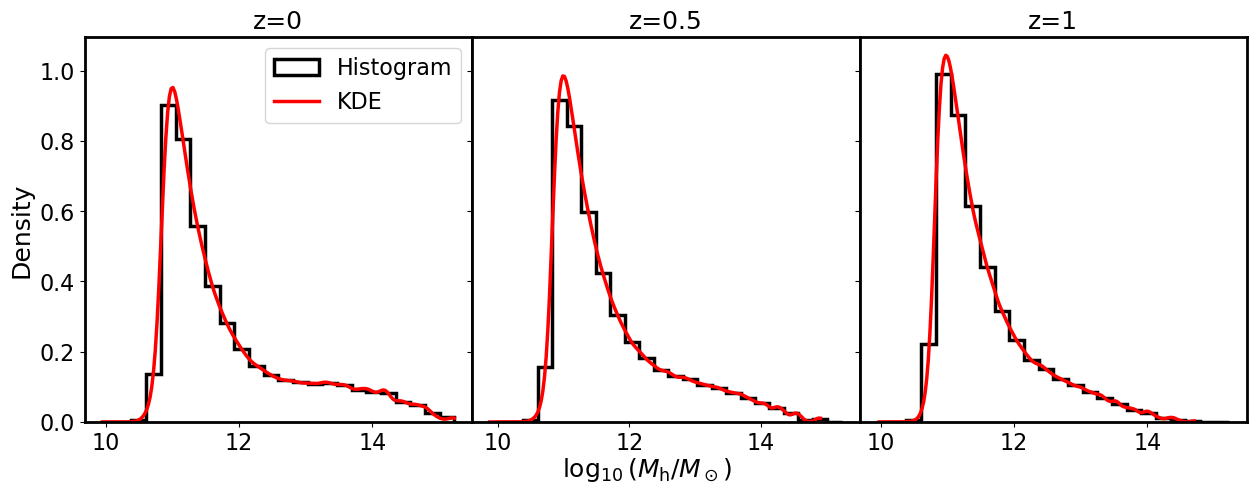

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.subplots_adjust(wspace=0)

########################################
# HALO MASS
########################################



axs[0].legend(loc='upper right', fontsize=16)
axs[0].set_ylabel("Density", fontsize=18)

axs[0].hist(HaloM_fig1_log, bins=bins_fig1, histtype='step', linewidth=2.5, color='black', density=True, label='Histogram')
axs[0].plot(KDE_xvals_fig1, KDE_yvals_fig1, color='red', linewidth=2.5, label='KDE')
axs[0].set_title("z=0", fontsize=18)

axs[1].hist(HaloM_fig1_log_z05, bins=bins_fig1, histtype='step', linewidth=2.5, color='black', density=True)
axs[1].plot(KDE_xvals_fig1_z05, KDE_yvals_fig1_z05, color='red', linewidth=2.5, label='KDE')
axs[1].set_title("z=0.5", fontsize=18)

axs[2].hist(HaloM_fig1_log_z1, bins=bins_fig1, histtype='step', linewidth=2.5, color='black', density=True)
axs[2].plot(KDE_xvals_fig1_z1, KDE_yvals_fig1_z1, color='red', linewidth=2.5, label='KDE')
axs[2].set_title("z=1", fontsize=18)

axs[0].legend(loc='upper right', fontsize=16)
axs[0].set_ylabel("Density", fontsize=18)



# Plot settings
#fig.supxlabel(r'$\log_{10}(\mathrm{M_*}/\mathrm{M}_\odot)$', fontsize=18)

fig.text(0.5, 0, r'$\log_{10}(M_{\mathrm{h}}/M_\odot)$', ha='center', fontsize=18)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<function matplotlib.pyplot.show(close=None, block=None)>

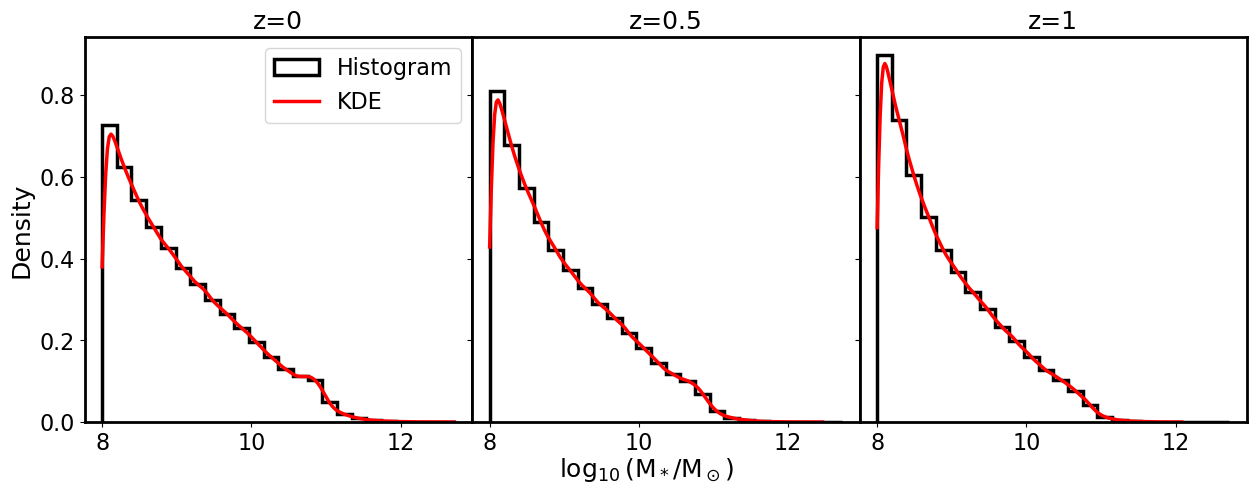

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.subplots_adjust(wspace=0)

########################################
# HALO MASS
########################################



axs[0].legend(loc='upper right', fontsize=16)
axs[0].set_ylabel("Density", fontsize=18)

axs[0].hist(StellarM_fig2_log, bins=bins_fig2, histtype='step', linewidth=2.5, color='black', density=True, label='Histogram')
axs[0].plot(KDE_xvals_fig2, KDE_yvals_fig2, color='red', linewidth=2.5, label='KDE')
axs[0].set_title("z=0", fontsize=18)

axs[1].hist(StellarM_fig2_log_z05, bins=bins_fig2, histtype='step', linewidth=2.5, color='black', density=True)
axs[1].plot(KDE_xvals_fig2_z05, KDE_yvals_fig2_z05, color='red', linewidth=2.5, label='KDE')
axs[1].set_title("z=0.5", fontsize=18)

axs[2].hist(StellarM_fig2_log_z1, bins=bins_fig2, histtype='step', linewidth=2.5, color='black', density=True)
axs[2].plot(KDE_xvals_fig2_z1, KDE_yvals_fig2_z1, color='red', linewidth=2.5, label='KDE')
axs[2].set_title("z=1", fontsize=18)

axs[0].legend(loc='upper right', fontsize=16)
axs[0].set_ylabel("Density", fontsize=18)



# Plot settings
#fig.supxlabel(r'$\log_{10}(\mathrm{M_*}/\mathrm{M}_\odot)$', fontsize=18)

fig.text(0.5, 0,r'$\log_{10}(\mathrm{M_*}/\mathrm{M}_\odot)$', ha='center', fontsize=18)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

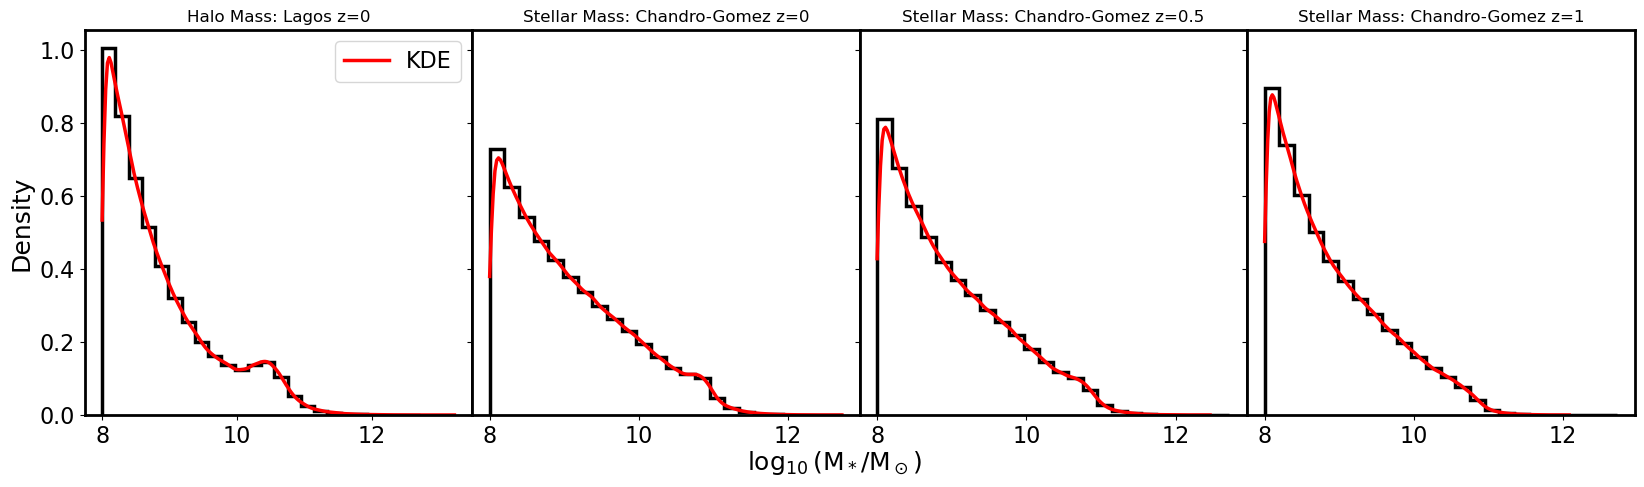

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

########################################
# STELLAR MASS
########################################

# Column 1: Hist+KDE. Lagos 24'. z=0.
axs[0].hist(StellarM_fig2_log_lagos, bins=bins_fig2, histtype='step', linewidth=2.5, color='black', density=True)
axs[0].plot(KDE_xvals_fig2_lagos, KDE_yvals_fig2_lagos, color='red', linewidth=2.5, label='KDE')
axs[0].set_title("Halo Mass: Lagos z=0")
axs[0].legend(loc='upper right', fontsize=16)
axs[0].set_ylabel("Density", fontsize=18)

# Column 2: Hist+KDE. Chandro-Gomez 25'. z=0.
axs[1].hist(StellarM_fig2_log, bins=bins_fig2, histtype='step', linewidth=2.5, color='black', density=True)
axs[1].plot(KDE_xvals_fig2, KDE_yvals_fig2, color='red', linewidth=2.5)
axs[1].set_title("Stellar Mass: Chandro-Gomez z=0")

# Column 3: Hist+KDE. Chandro-Gomez 25'. z=0.5.
axs[2].hist(StellarM_fig2_log_z05, bins=bins_fig2, histtype='step', linewidth=2.5, color='black', density=True)
axs[2].plot(KDE_xvals_fig2_z05, KDE_yvals_fig2_z05, color='red', linewidth=2.5, label='KDE')
axs[2].set_title("Stellar Mass: Chandro-Gomez z=0.5")

# Column 4: Hist+KDE. Chandro-Gomez 25'. z=1.
axs[3].hist(StellarM_fig2_log_z1, bins=bins_fig2, histtype='step', linewidth=2.5, color='black', density=True)
axs[3].plot(KDE_xvals_fig2_z1, KDE_yvals_fig2_z1, color='red', linewidth=2.5, label='KDE')
axs[3].set_title("Stellar Mass: Chandro-Gomez z=1")



# Plot settings
#fig.supxlabel(r'$\log_{10}(\mathrm{M_*}/\mathrm{M}_\odot)$', fontsize=18)

fig.text(0.5, 0,r'$\log_{10}(\mathrm{M_*}/\mathrm{M}_\odot)$', ha='center', fontsize=18)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

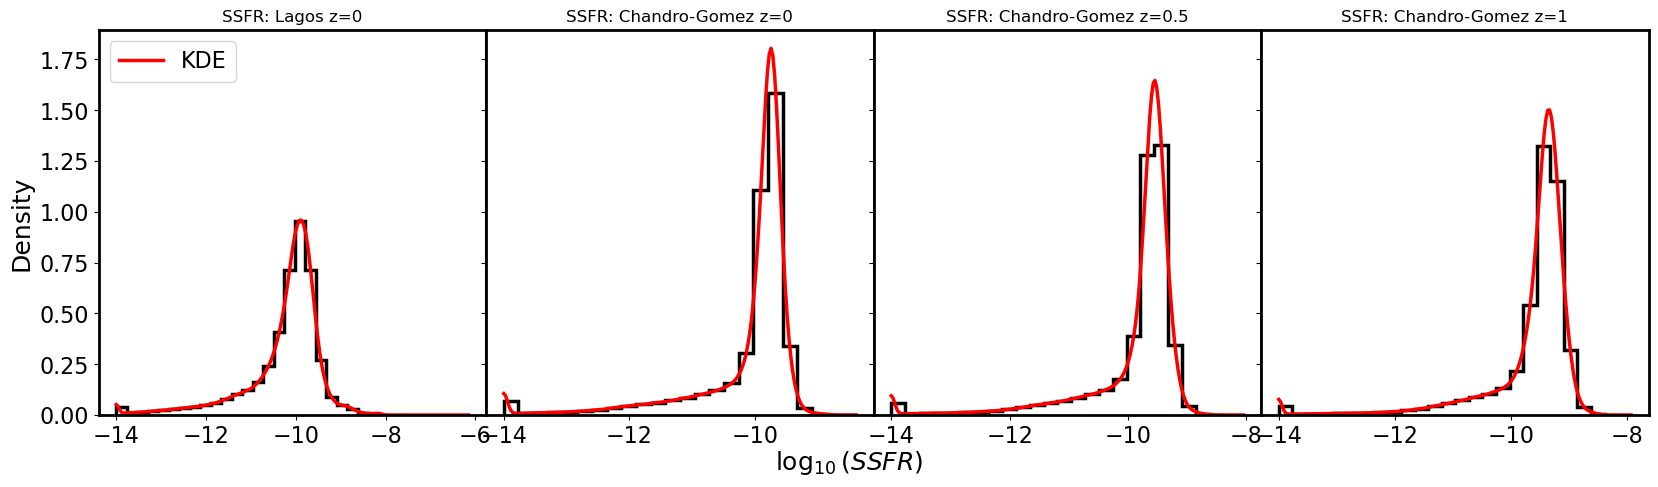

In [14]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

########################################
# SSFR
########################################

# Column 1: Hist+KDE. Lagos 24'. z=0.
axs[0].hist(SSFR_fig3_log_lagos, bins=bins_fig3, histtype='step', linewidth=2.5, color='black', density=True)
axs[0].plot(SSFR_KDE_xvals_fig3_lagos, SSFR_KDE_yvals_fig3_lagos, color='red', linewidth=2.5,  label='KDE')
axs[0].set_title("SSFR: Lagos z=0")
axs[0].legend(loc='upper left', fontsize=16)
axs[0].set_ylabel("Density", fontsize=18)

# Column 2: Hist+KDE. Chandro-Gomez 25'. z=0.
axs[1].hist(SSFR_fig3_log, bins=bins_fig3, histtype='step', linewidth=2.5, color='black', density=True)
axs[1].plot(SSFR_KDE_xvals_fig3, SSFR_KDE_yvals_fig3, color='red', linewidth=2.5)
axs[1].set_title("SSFR: Chandro-Gomez z=0")

# Column 3: Hist+KDE. Chandro-Gomez 25'. z=0.5.
axs[2].hist(SSFR_fig3_log_z05, bins=bins_fig3, histtype='step', linewidth=2.5, color='black', density=True)
axs[2].plot(SSFR_KDE_xvals_fig3_z05,SSFR_KDE_yvals_fig3_z05 , color='red', linewidth=2.5, label='KDE')
axs[2].set_title("SSFR: Chandro-Gomez z=0.5")

# Column 4: Hist+KDE. Chandro-Gomez 25'. z=1.
axs[3].hist(SSFR_fig3_log_z1, bins=bins_fig3, histtype='step', linewidth=2.5, color='black', density=True)
axs[3].plot(SSFR_KDE_xvals_fig3_z1, SSFR_KDE_yvals_fig3_z1, color='red', linewidth=2.5, label='KDE')
axs[3].set_title("SSFR: Chandro-Gomez z=1")

# Plot settings
fig.text(0.5, 0,r'$\log_{10}(SSFR)$', ha='center', fontsize=18)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show

Lagos Min=  9.816054136206564 Max=  14.972738287330559
Chandro-Gomez 25'. z=0. Min=  9.94713017270628 Max=  15.2323102444803
Chandro-Gomez 25'. z=0.5. Min=  9.877494238095126 Max=  14.906068846556208
Chandro-Gomez 25'. z=1. Min=  9.97816437437632 Max=  14.70542160494771


<function matplotlib.pyplot.show(close=None, block=None)>

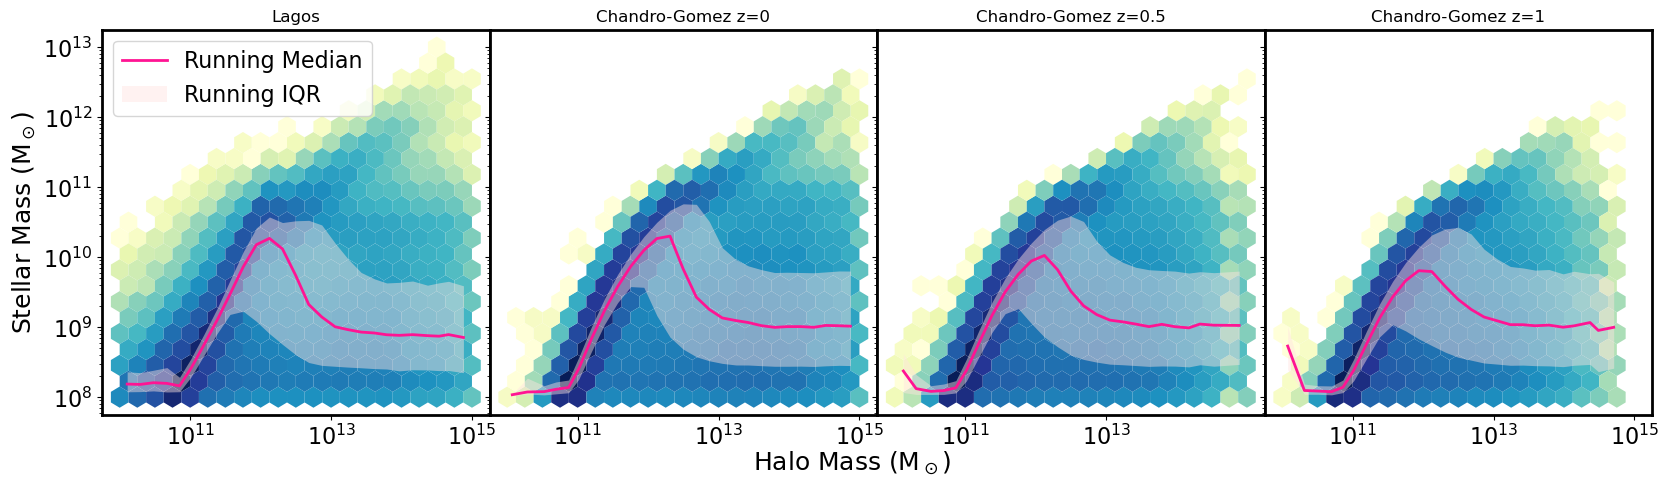

In [15]:
########################################
# Stellar Mass vs. Halo Mass
########################################

fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

########################################
# Column 1: Stellar vs. Halo Hexbin. Lagos.
########################################
hb_lagos = axs[0].hexbin(shark_csv_lagos['Mhalo_host'], shark_csv_lagos['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))
axs[0].set_title("Lagos")
axs[0].set_ylabel(r'Stellar Mass (M$_\odot$)', fontsize=18)

print("Lagos Min= ", np.min(np.log10(shark_csv_lagos['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_lagos['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_lagos['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_lagos['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_lagos['Mhalo_host'], shark_csv_lagos['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_lagos['Mhalo_host'][(shark_csv_lagos['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_lagos['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_lagos['Mhalo_host'], shark_csv_lagos['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_lagos['Mhalo_host'], shark_csv_lagos['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')

# Column 1: Legend
axs[0].legend(loc='upper left', fontsize=16)

########################################
# Column 2: Stellar vs. Halo Hexbin. Chandro-Gomez 25'. z=0.
########################################
hb_CGz0 = axs[1].hexbin(shark_csv['Mhalo_host'], shark_csv['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                        extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))
axs[1].set_title("Chandro-Gomez z=0")
# Column 1: y axis label

print("Chandro-Gomez 25'. z=0. Min= ", np.min(np.log10(shark_csv['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog = math.log10(shark_csv['Mhalo_host'].min())
highLog = math.log10(shark_csv['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog = round(lowLog, 0)
highLog = round(highLog, 0)

# Create log bins
num_bins = 27 #27 bins for all plots
logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

# MEDIAN for y-values
result = binned_statistic(shark_csv['Mhalo_host'], shark_csv['Mstar_all'], statistic='median', bins=logBins)
bin_medians = result.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals = []
for j in range(len(logBins) - 1):
    # Filter data points within the current bin
    bin_data = shark_csv['Mhalo_host'][(shark_csv['Mhalo_host'] >= logBins[j]) & (shark_csv['Mhalo_host'] < logBins[j+1])]
    if len(bin_data) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals.append(np.median(bin_data))
    else:
        # If no data points in the bin, append NaN or skip
        xVals.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals = np.array(xVals)
valid_bins = ~np.isnan(xVals)
xVals = xVals[valid_bins]
bin_medians = bin_medians[valid_bins]

# PERCENTILES
# 25th percentile
percentile_25 = binned_statistic(shark_csv['Mhalo_host'], shark_csv['Mstar_all'], statistic=lambda values: np.percentile(values, 25), bins=logBins)
p25 = percentile_25.statistic[valid_bins]
# 75th percentile
percentile_75 = binned_statistic(shark_csv['Mhalo_host'], shark_csv['Mstar_all'], statistic=lambda values: np.percentile(values, 75), bins=logBins)
p75 = percentile_75.statistic[valid_bins]

axs[1].plot(xVals, bin_medians, linewidth=2, color='deeppink', label='Running Median')
axs[1].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.45, label='Running IQR', linewidth=0)

########################################
# Column 3: Stellar vs. Halo Hexbin. Chandro-Gomez 25'. z=0.5.
########################################
hb_CGz05 = axs[2].hexbin(shark_csv_z05['Mhalo_host'], shark_csv_z05['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                        extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))
axs[2].set_title("Chandro-Gomez z=0.5")

print("Chandro-Gomez 25'. z=0.5. Min= ", np.min(np.log10(shark_csv_z05['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_z05['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_z05 = math.log10(shark_csv_z05['Mhalo_host'].min())
highLog_z05 = math.log10(shark_csv_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_z05 = round(lowLog_z05, 0)
highLog_z05 = round(highLog_z05, 0)

# Create log bins
logBins_z05 = np.logspace(lowLog_z05, highLog_z05, num=num_bins + 1)

# MEDIAN for y-values
result_z05 = binned_statistic(shark_csv_z05['Mhalo_host'], shark_csv_z05['Mstar_all'], statistic='median', bins=logBins_z05)
bin_medians_z05 = result_z05.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_z05 = []
for j in range(len(logBins_z05) - 1):
    # Filter data points within the current bin
    bin_data_z05 = shark_csv_z05['Mhalo_host'][(shark_csv_z05['Mhalo_host'] >= logBins_z05[j]) & (shark_csv_z05['Mhalo_host'] < logBins_z05[j+1])]
    if len(bin_data_z05) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_z05.append(np.median(bin_data_z05))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_z05.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_z05 = np.array(xVals_z05)
valid_bins_z05 = ~np.isnan(xVals_z05)
xVals_z05 = xVals_z05[valid_bins_z05]
bin_medians_z05 = bin_medians_z05[valid_bins_z05]

# PERCENTILES
# 25th percentile
percentile_25_z05 = binned_statistic(shark_csv_z05['Mhalo_host'], shark_csv_z05['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_z05)
p25_z05 = percentile_25_z05.statistic[valid_bins_z05]
# 75th percentile
percentile_75_z05 = binned_statistic(shark_csv_z05['Mhalo_host'], shark_csv_z05['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_z05)
p75_z05 = percentile_75_z05.statistic[valid_bins_z05]

axs[2].plot(xVals_z05, bin_medians_z05, linewidth=2, color='deeppink')
axs[2].fill_between(xVals_z05, p25_z05, p75_z05, color='mistyrose', alpha=0.45, linewidth=0)
axs[2].set_xticks([10**11,10**13])

#print('bin medians z=0.5', bin_medians_z05)
#print('p25 z=0.5', p25_z05)

########################################
# Column 4: Stellar vs. Halo Hexbin. Chandro-Gomez 25'. z=1.
########################################
hb_CGz1 = axs[3].hexbin(shark_csv_z1['Mhalo_host'], shark_csv_z1['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                       extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))
axs[3].set_title("Chandro-Gomez z=1")

print("Chandro-Gomez 25'. z=1. Min= ", np.min(np.log10(shark_csv_z1['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv_z1['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_z1 = math.log10(shark_csv_z1['Mhalo_host'].min())
highLog_z1 = math.log10(shark_csv_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_z1 = round(lowLog_z1, 0)
highLog_z1 = round(highLog_z1, 0)

# Create log bins
logBins_z1 = np.logspace(lowLog_z1, highLog_z1, num=num_bins + 1)

# MEDIAN for y-values
result_z1 = binned_statistic(shark_csv_z1['Mhalo_host'], shark_csv_z1['Mstar_all'], statistic='median', bins=logBins_z1)
bin_medians_z1 = result_z1.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_z1 = []
for j in range(len(logBins_z1) - 1):
    # Filter data points within the current bin
    bin_data_z1 = shark_csv_z1['Mhalo_host'][(shark_csv_z1['Mhalo_host'] >= logBins_z1[j]) & (shark_csv_z1['Mhalo_host'] < logBins_z1[j+1])]
    if len(bin_data_z1) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_z1.append(np.median(bin_data_z1))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_z1.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_z1 = np.array(xVals_z1)
valid_bins_z1 = ~np.isnan(xVals_z1)
xVals_z1 = xVals_z1[valid_bins_z1]
bin_medians_z1 = bin_medians_z1[valid_bins_z1]

# PERCENTILES
# 25th percentile
percentile_25_z1 = binned_statistic(shark_csv_z1['Mhalo_host'], shark_csv_z1['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_z1)
p25_z1 = percentile_25_z1.statistic[valid_bins_z1]
# 75th percentile
percentile_75_z1 = binned_statistic(shark_csv_z1['Mhalo_host'], shark_csv_z1['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_z1)
p75_z1 = percentile_75_z1.statistic[valid_bins_z1]

axs[3].plot(xVals_z1, bin_medians_z1, linewidth=2, color='deeppink')
axs[3].fill_between(xVals_z1, p25_z1, p75_z1, color='mistyrose', alpha=0.45, linewidth=0)

#print('xVals_lagos: ',xVals_lagos)
#print('bin_medians_lagos: ',bin_medians_lagos)
#print('p25_lagos:',p25_lagos) 

# Misc. Settings
fig.text(0.5, 0,r'Halo Mass (M$_\odot$)', ha='center', fontsize=18)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show

In [16]:
# Settings to filter centrals and satellites
shark_csv_centrals = shark_csv[(shark_csv['type'] == 0)] ######## Centrals only
shark_csv_satellites = shark_csv[(shark_csv['type'] == 1)] ######## Satellites only

shark_csv_centrals_z05 = shark_csv_z05[(shark_csv_z05['type'] == 0)] ######## Centrals only
shark_csv_satellites_z05 = shark_csv_z05[(shark_csv_z05['type'] == 1)] ######## Satellites only

shark_csv_centrals_z1 = shark_csv_z1[(shark_csv_z1['type'] == 0)] ######## Centrals only
shark_csv_satellites_z1 = shark_csv_z1[(shark_csv_z1['type'] == 1)] ######## Satellites only

shark_csv_centrals_lagos = shark_csv_lagos[(shark_csv_lagos['type'] == 0)] ######## Centrals only
shark_csv_satellites_lagos = shark_csv_lagos[(shark_csv_lagos['type'] == 1)] ######## Satellites only


<function matplotlib.pyplot.show(close=None, block=None)>

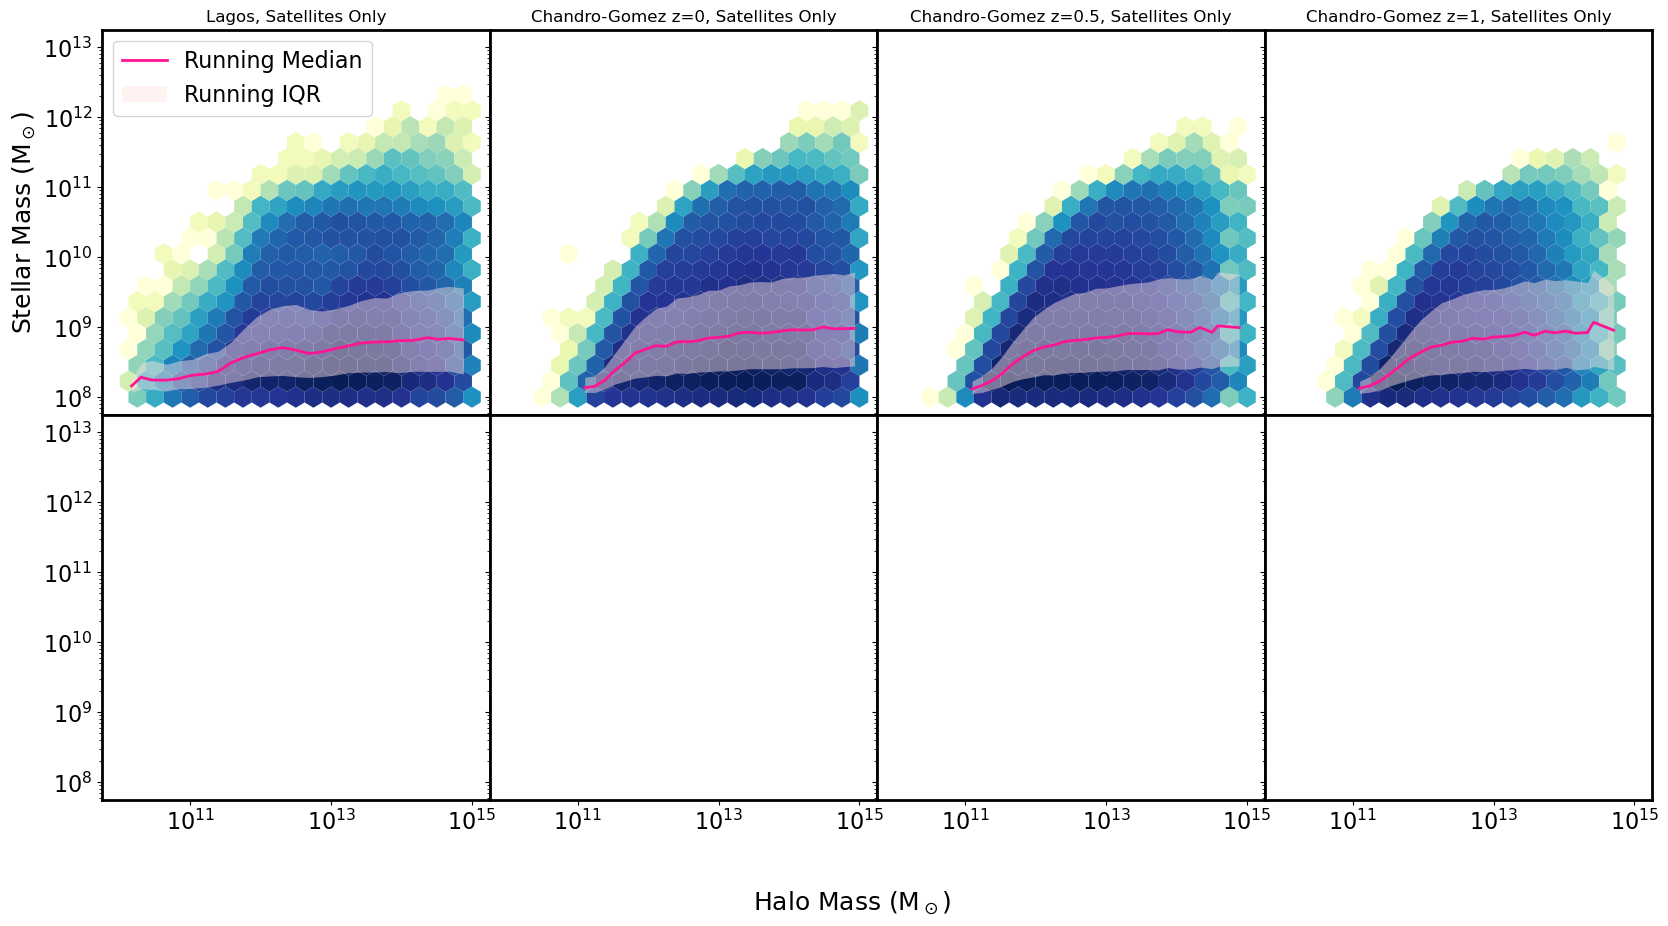

In [17]:
########################################
# Stellar Mass vs. Halo Mass - SATELLITES
########################################

fig, axs = plt.subplots(2, 4, figsize=(20, 10), sharey=True, sharex=True)
fig.subplots_adjust(wspace=0, hspace=0)

########################################
# Column 4: Stellar vs. Halo Hexbin. Lagos.
########################################
hb_lagos = axs[0,0].hexbin(shark_csv_satellites_lagos['Mhalo_host'], shark_csv_satellites_lagos['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                        extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))
axs[0,0].set_title("Lagos, Satellites Only")
# Column 1: y axis label
axs[0,0].set_ylabel(r'Stellar Mass (M$_\odot$)', fontsize=18)


# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_satellites_lagos['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_satellites_lagos['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_satellites_lagos['Mhalo_host'], shark_csv_satellites_lagos['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_satellites_lagos['Mhalo_host'][(shark_csv_satellites_lagos['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_satellites_lagos['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_satellites_lagos['Mhalo_host'], shark_csv_satellites_lagos['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_satellites_lagos['Mhalo_host'], shark_csv_satellites_lagos['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[0,0].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink', label='Running Median')
axs[0,0].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0, label='Running IQR')
# Column 1: Legend
axs[0,0].legend(loc='upper left', fontsize=16)

########################################
# Column 1: Stellar vs. Halo Hexbin. Chandro-Gomez 25'. z=0.
########################################
hb_CGz0 = axs[0,1].hexbin(shark_csv_satellites['Mhalo_host'], shark_csv_satellites['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                       extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))
axs[0,1].set_title("Chandro-Gomez z=0, Satellites Only")

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog = math.log10(shark_csv_satellites['Mhalo_host'].min())
highLog = math.log10(shark_csv_satellites['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog = round(lowLog, 0)
highLog = round(highLog, 0)

# Create log bins
num_bins = 27 #27 bins for all plots
logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

# MEDIAN for y-values
result = binned_statistic(shark_csv_satellites['Mhalo_host'], shark_csv_satellites['Mstar_all'], statistic='median', bins=logBins)
bin_medians = result.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals = []
for j in range(len(logBins) - 1):
    # Filter data points within the current bin
    bin_data = shark_csv_satellites['Mhalo_host'][(shark_csv_satellites['Mhalo_host'] >= logBins[j]) & (shark_csv_satellites['Mhalo_host'] < logBins[j+1])]
    if len(bin_data) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals.append(np.median(bin_data))
    else:
        # If no data points in the bin, append NaN or skip
        xVals.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals = np.array(xVals)
valid_bins = ~np.isnan(xVals)
xVals = xVals[valid_bins]
bin_medians = bin_medians[valid_bins]

# PERCENTILES
# 25th percentile
percentile_25 = binned_statistic(shark_csv_satellites['Mhalo_host'], shark_csv_satellites['Mstar_all'], statistic=lambda values: np.percentile(values, 25), bins=logBins)
p25 = percentile_25.statistic[valid_bins]
# 75th percentile
percentile_75 = binned_statistic(shark_csv_satellites['Mhalo_host'], shark_csv_satellites['Mstar_all'], statistic=lambda values: np.percentile(values, 75), bins=logBins)
p75 = percentile_75.statistic[valid_bins]

axs[0,1].plot(xVals, bin_medians, linewidth=2, color='deeppink')
axs[0,1].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.45, label='Running IQR', linewidth=0)

#print('bin medians z=0', bin_medians)
#print('p25 z=0', p25)
#print('xVals: ',xVals)

########################################
# Column 2: Stellar vs. Halo Hexbin. Chandro-Gomez 25'. z=0.5.
########################################
hb_CGz05 = axs[0,2].hexbin(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                         extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))
axs[0,2].set_title("Chandro-Gomez z=0.5, Satellites Only")

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_z05 = math.log10(shark_csv_satellites_z05['Mhalo_host'].min())
highLog_z05 = math.log10(shark_csv_satellites_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_z05 = round(lowLog_z05, 0)
highLog_z05 = round(highLog_z05, 0)

# Create log bins
logBins_z05 = np.logspace(lowLog_z05, highLog_z05, num=num_bins + 1)

# MEDIAN for y-values
result_z05 = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['Mstar_all'], statistic='median', bins=logBins_z05)
bin_medians_z05 = result_z05.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_z05 = []
for j in range(len(logBins_z05) - 1):
    # Filter data points within the current bin
    bin_data_z05 = shark_csv_satellites_z05['Mhalo_host'][(shark_csv_satellites_z05['Mhalo_host'] >= logBins_z05[j]) & (shark_csv_satellites_z05['Mhalo_host'] < logBins_z05[j+1])]
    if len(bin_data_z05) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_z05.append(np.median(bin_data_z05))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_z05.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_z05 = np.array(xVals_z05)
valid_bins_z05 = ~np.isnan(xVals_z05)
xVals_z05 = xVals_z05[valid_bins_z05]
bin_medians_z05 = bin_medians_z05[valid_bins_z05]

# PERCENTILES
# 25th percentile
percentile_25_z05 = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_z05)
p25_z05 = percentile_25_z05.statistic[valid_bins_z05]
# 75th percentile
percentile_75_z05 = binned_statistic(shark_csv_satellites_z05['Mhalo_host'], shark_csv_satellites_z05['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_z05)
p75_z05 = percentile_75_z05.statistic[valid_bins_z05]

axs[0,2].plot(xVals_z05, bin_medians_z05, linewidth=2, color='deeppink')
axs[0,2].fill_between(xVals_z05, p25_z05, p75_z05, color='mistyrose', alpha=0.45, linewidth=0)

#print('bin medians z=0.5', bin_medians_z05)
#print('p25 z=0.5', p25_z05)

########################################
# Column 3: Stellar vs. Halo Hexbin. Chandro-Gomez 25'. z=1.
########################################
hb_CGz1 = axs[0,3].hexbin(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                       extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))
axs[0,3].set_title("Chandro-Gomez z=1, Satellites Only")

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_z1 = math.log10(shark_csv_satellites_z1['Mhalo_host'].min())
highLog_z1 = math.log10(shark_csv_satellites_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_z1 = round(lowLog_z1, 0)
highLog_z1 = round(highLog_z1, 0)

# Create log bins
logBins_z1 = np.logspace(lowLog_z1, highLog_z1, num=num_bins + 1)

# MEDIAN for y-values
result_z1 = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['Mstar_all'], statistic='median', bins=logBins_z1)
bin_medians_z1 = result_z1.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_z1 = []
for j in range(len(logBins_z1) - 1):
    # Filter data points within the current bin
    bin_data_z1 = shark_csv_satellites_z1['Mhalo_host'][(shark_csv_satellites_z1['Mhalo_host'] >= logBins_z1[j]) & (shark_csv_satellites_z1['Mhalo_host'] < logBins_z1[j+1])]
    if len(bin_data_z1) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_z1.append(np.median(bin_data_z1))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_z1.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_z1 = np.array(xVals_z1)
valid_bins_z1 = ~np.isnan(xVals_z1)
xVals_z1 = xVals_z1[valid_bins_z1]
bin_medians_z1 = bin_medians_z1[valid_bins_z1]

# PERCENTILES
# 25th percentile
percentile_25_z1 = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_z1)
p25_z1 = percentile_25_z1.statistic[valid_bins_z1]
# 75th percentile
percentile_75_z1 = binned_statistic(shark_csv_satellites_z1['Mhalo_host'], shark_csv_satellites_z1['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_z1)
p75_z1 = percentile_75_z1.statistic[valid_bins_z1]

axs[0,3].plot(xVals_z1, bin_medians_z1, linewidth=2, color='deeppink')
axs[0,3].fill_between(xVals_z1, p25_z1, p75_z1, color='mistyrose', alpha=0.45, linewidth=0)


# Misc. Settings
fig.text(0.5, 0,r'Halo Mass (M$_\odot$)', ha='center', fontsize=18)

for ax in axs.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

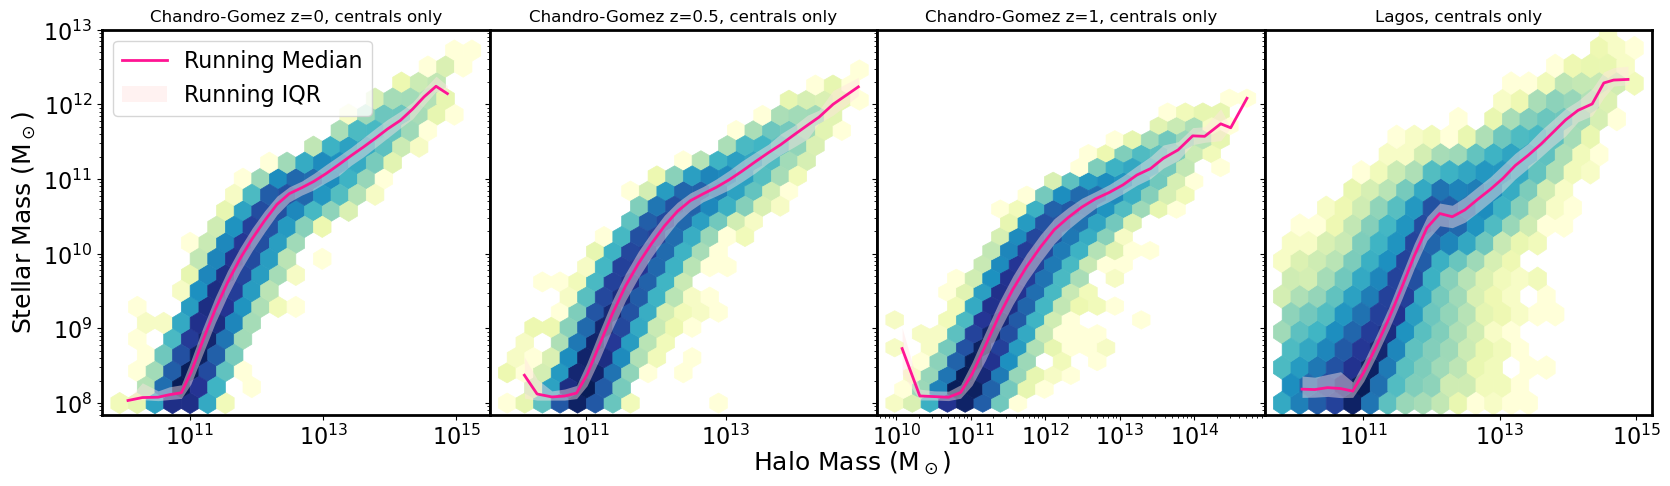

In [18]:
########################################
# Stellar Mass vs. Halo Mass - CENTRALS
########################################

fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

# Set a shared y-axis range
y_min = 7*10**7
y_max = 10**13

########################################
# Column 1: Stellar vs. Halo Hexbin. Chandro-Gomez 25'. z=0.
########################################
hb_CGz0 = axs[0].hexbin(shark_csv_centrals['Mhalo_host'], shark_csv_centrals['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0.5, cmap='YlGnBu')
axs[0].set_title("Chandro-Gomez z=0, centrals only")
# Column 1: y axis label
axs[0].set_ylabel(r'Stellar Mass (M$_\odot$)', fontsize=18)
axs[0].set_ylim([y_min, y_max])

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog = math.log10(shark_csv_centrals['Mhalo_host'].min())
highLog = math.log10(shark_csv_centrals['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog = round(lowLog, 0)
highLog = round(highLog, 0)

# Create log bins
num_bins = 27 #27 bins for all plots
logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

# MEDIAN for y-values
result = binned_statistic(shark_csv_centrals['Mhalo_host'], shark_csv_centrals['Mstar_all'], statistic='median', bins=logBins)
bin_medians = result.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals = []
for j in range(len(logBins) - 1):
    # Filter data points within the current bin
    bin_data = shark_csv_centrals['Mhalo_host'][(shark_csv_centrals['Mhalo_host'] >= logBins[j]) & (shark_csv_centrals['Mhalo_host'] < logBins[j+1])]
    if len(bin_data) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals.append(np.median(bin_data))
    else:
        # If no data points in the bin, append NaN or skip
        xVals.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals = np.array(xVals)
valid_bins = ~np.isnan(xVals)
xVals = xVals[valid_bins]
bin_medians = bin_medians[valid_bins]

# PERCENTILES
# 25th percentile
percentile_25 = binned_statistic(shark_csv_centrals['Mhalo_host'], shark_csv_centrals['Mstar_all'], statistic=lambda values: np.percentile(values, 25), bins=logBins)
p25 = percentile_25.statistic[valid_bins]
# 75th percentile
percentile_75 = binned_statistic(shark_csv_centrals['Mhalo_host'], shark_csv_centrals['Mstar_all'], statistic=lambda values: np.percentile(values, 75), bins=logBins)
p75 = percentile_75.statistic[valid_bins]

axs[0].plot(xVals, bin_medians, linewidth=2, color='deeppink', label='Running Median')
axs[0].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.45, label='Running IQR', linewidth=0)

# Column 1: Legend
axs[0].legend(loc='upper left', fontsize=16)

#print('bin medians z=0', bin_medians)
#print('p25 z=0', p25)
#print('xVals: ',xVals)

########################################
# Column 2: Stellar vs. Halo Hexbin. Chandro-Gomez 25'. z=0.5.
########################################
hb_CGz05 = axs[1].hexbin(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0.5, cmap='YlGnBu')
axs[1].set_title("Chandro-Gomez z=0.5, centrals only")
axs[1].set_ylim([y_min, y_max])

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_z05 = math.log10(shark_csv_centrals_z05['Mhalo_host'].min())
highLog_z05 = math.log10(shark_csv_centrals_z05['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_z05 = round(lowLog_z05, 0)
highLog_z05 = round(highLog_z05, 0)

# Create log bins
logBins_z05 = np.logspace(lowLog_z05, highLog_z05, num=num_bins + 1)

# MEDIAN for y-values
result_z05 = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['Mstar_all'], statistic='median', bins=logBins_z05)
bin_medians_z05 = result_z05.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_z05 = []
for j in range(len(logBins_z05) - 1):
    # Filter data points within the current bin
    bin_data_z05 = shark_csv_centrals_z05['Mhalo_host'][(shark_csv_centrals_z05['Mhalo_host'] >= logBins_z05[j]) & (shark_csv_centrals_z05['Mhalo_host'] < logBins_z05[j+1])]
    if len(bin_data_z05) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_z05.append(np.median(bin_data_z05))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_z05.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_z05 = np.array(xVals_z05)
valid_bins_z05 = ~np.isnan(xVals_z05)
xVals_z05 = xVals_z05[valid_bins_z05]
bin_medians_z05 = bin_medians_z05[valid_bins_z05]

# PERCENTILES
# 25th percentile
percentile_25_z05 = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_z05)
p25_z05 = percentile_25_z05.statistic[valid_bins_z05]
# 75th percentile
percentile_75_z05 = binned_statistic(shark_csv_centrals_z05['Mhalo_host'], shark_csv_centrals_z05['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_z05)
p75_z05 = percentile_75_z05.statistic[valid_bins_z05]

axs[1].plot(xVals_z05, bin_medians_z05, linewidth=2, color='deeppink')
axs[1].fill_between(xVals_z05, p25_z05, p75_z05, color='mistyrose', alpha=0.45, linewidth=0)
axs[1].set_xticks([10**11,10**13])

#print('bin medians z=0.5', bin_medians_z05)
#print('p25 z=0.5', p25_z05)

########################################
# Column 3: Stellar vs. Halo Hexbin. Chandro-Gomez 25'. z=1.
########################################
hb_CGz1 = axs[2].hexbin(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0.5, cmap='YlGnBu')
axs[2].set_title("Chandro-Gomez z=1, centrals only")
axs[2].set_ylim([y_min, y_max])

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_z1 = math.log10(shark_csv_centrals_z1['Mhalo_host'].min())
highLog_z1 = math.log10(shark_csv_centrals_z1['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_z1 = round(lowLog_z1, 0)
highLog_z1 = round(highLog_z1, 0)

# Create log bins
logBins_z1 = np.logspace(lowLog_z1, highLog_z1, num=num_bins + 1)

# MEDIAN for y-values
result_z1 = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['Mstar_all'], statistic='median', bins=logBins_z1)
bin_medians_z1 = result_z1.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_z1 = []
for j in range(len(logBins_z1) - 1):
    # Filter data points within the current bin
    bin_data_z1 = shark_csv_centrals_z1['Mhalo_host'][(shark_csv_centrals_z1['Mhalo_host'] >= logBins_z1[j]) & (shark_csv_centrals_z1['Mhalo_host'] < logBins_z1[j+1])]
    if len(bin_data_z1) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_z1.append(np.median(bin_data_z1))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_z1.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_z1 = np.array(xVals_z1)
valid_bins_z1 = ~np.isnan(xVals_z1)
xVals_z1 = xVals_z1[valid_bins_z1]
bin_medians_z1 = bin_medians_z1[valid_bins_z1]

# PERCENTILES
# 25th percentile
percentile_25_z1 = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_z1)
p25_z1 = percentile_25_z1.statistic[valid_bins_z1]
# 75th percentile
percentile_75_z1 = binned_statistic(shark_csv_centrals_z1['Mhalo_host'], shark_csv_centrals_z1['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_z1)
p75_z1 = percentile_75_z1.statistic[valid_bins_z1]

axs[2].plot(xVals_z1, bin_medians_z1, linewidth=2, color='deeppink')
axs[2].fill_between(xVals_z1, p25_z1, p75_z1, color='mistyrose', alpha=0.45, linewidth=0)

########################################
# Column 4: Stellar vs. Halo Hexbin. Lagos.
########################################
hb_lagos = axs[3].hexbin(shark_csv_centrals_lagos['Mhalo_host'], shark_csv_centrals_lagos['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0.5, cmap='YlGnBu')
axs[3].set_title("Lagos, centrals only")
axs[3].set_ylim([y_min, y_max])

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_lagos = math.log10(shark_csv_centrals_lagos['Mhalo_host'].min())
highLog_lagos = math.log10(shark_csv_centrals_lagos['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_lagos = round(lowLog_lagos, 0)
highLog_lagos = round(highLog_lagos, 0)

# Create log bins
num_bins = 27
logBins_lagos = np.logspace(lowLog_lagos, highLog_lagos, num=num_bins + 1)

# MEDIAN for y-values
result_lagos = binned_statistic(shark_csv_centrals_lagos['Mhalo_host'], shark_csv_centrals_lagos['Mstar_all'], statistic='median', bins=logBins_lagos)
bin_medians_lagos = result_lagos.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_lagos = []
for j in range(len(logBins_lagos) - 1):
    # Filter data points within the current bin
    bin_data_lagos = shark_csv_centrals_lagos['Mhalo_host'][(shark_csv_centrals_lagos['Mhalo_host'] >= logBins_lagos[j]) & (shark_csv_centrals_lagos['Mhalo_host'] < logBins_lagos[j+1])]
    if len(bin_data_lagos) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_lagos.append(np.median(bin_data_lagos))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_lagos.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_lagos = np.array(xVals_lagos)
valid_bins_lagos = ~np.isnan(xVals_lagos)
xVals_lagos = xVals_lagos[valid_bins_lagos]
bin_medians_lagos = bin_medians_lagos[valid_bins_lagos]

# PERCENTILES
# 25th percentile
percentile_25_lagos = binned_statistic(shark_csv_centrals_lagos['Mhalo_host'], shark_csv_centrals_lagos['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_lagos)
p25_lagos = percentile_25_lagos.statistic[valid_bins_lagos]
# 75th percentile
percentile_75_lagos = binned_statistic(shark_csv_centrals_lagos['Mhalo_host'], shark_csv_centrals_lagos['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_lagos)
p75_lagos = percentile_75_lagos.statistic[valid_bins_lagos]

axs[3].plot(xVals_lagos, bin_medians_lagos, linewidth=2, color='deeppink')
axs[3].fill_between(xVals_lagos, p25_lagos, p75_lagos, color='mistyrose', alpha=0.45, linewidth=0)

#print('xVals_lagos: ',xVals_lagos)
#print('bin_medians_lagos: ',bin_medians_lagos)
#print('p25_lagos:',p25_lagos) 

# Misc. Settings
fig.text(0.5, 0,r'Halo Mass (M$_\odot$)', ha='center', fontsize=18)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show

In [ ]:
########## SFR CSV (LAGOS SHARK)
file_path2 = "SFR.csv"

SFRline = pd.read_csv(file_path2, header=None)
SFRline.columns = ["Column1", "Column2"]
SFRline = SFRline.sort_values(by="Column1")
SFRline = 10 ** SFRline

########## Brinchmann
file_path3 = "Brinchmann.csv"

Brinchmann = pd.read_csv(file_path3, header=None)
Brinchmann.columns = ["Column1", "Column2"]
Brinchmann = Brinchmann.sort_values(by="Column1")
Brinchmann = 10 ** Brinchmann

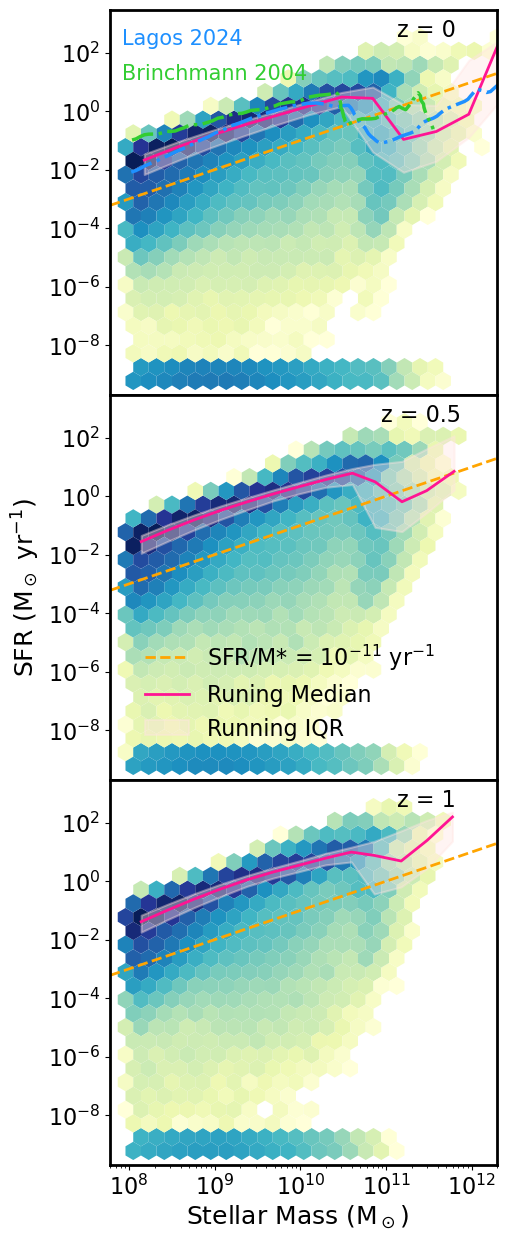

In [100]:
########################################
# Star forming main sequence
########################################
# List of datasets for easy iteration
datasets = [("z=0", shark_csv),
            ("z=0.5", shark_csv_z05),
            ("z=1", shark_csv_z1)]

sfr_threshold = 10**-9

# Create a 1x4 grid of subplots
fig, axs = plt.subplots(3, 1, figsize=(5, 15), sharex=True)
fig.subplots_adjust(hspace=0)

# Set a shared x and y-axis range
y_min = 2*10**-10
y_max = 3*10**3
x_min = 6*10**7
x_max = 2*10**12

# Code for diagonal sSFR line
x = np.logspace(np.log10(x_min), np.log10(x_max), 100)  # Generate stellar mass range
sfr_line = x * 10**-11

# Apply this range and ticks to all subplots
for ax in axs:
    ax.set_ylim([y_min, y_max])
    ax.set_xlim([x_min, x_max])
    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())  # Use scalar format for readability

# Loop through each dataset and create a plot
for i, (title, data) in enumerate(datasets):
    #data = data[data['type'] == 1]
    # Modify only the 'SFR_all' column in place
    data.loc[data['SFR_all'] < sfr_threshold, 'SFR_all'] = sfr_threshold
    
    # Calculate min and max log values of Mhalo_host
    lowLog = math.log10(data['Mstar_all'].min())
    highLog = math.log10(data['Mstar_all'].max())

    # Round to the nearest whole number for log binning
    lowLog = round(lowLog, 0)
    highLog = round(highLog, 0)

    # Create log bins
    num_bins = 13
    logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

    # MEDIAN for y-values
    result = binned_statistic(data['Mstar_all'], data['SFR_all'], statistic='median', bins=logBins)
    bin_medians = result.statistic

    # Calculate xVals by finding the median Mhalo_host value within each bin
    xVals = []
    for j in range(len(logBins) - 1):
        # Filter data points within the current bin
        bin_data = data['Mstar_all'][(data['Mstar_all'] >= logBins[j]) & (data['Mstar_all'] < logBins[j+1])]
        if len(bin_data) > 0:
            # Append the median of Mhalo_host values in the bin to xVals
            xVals.append(np.median(bin_data))
        else:
            # If no data points in the bin, append NaN or skip
            xVals.append(np.nan)

    # Convert xVals to a numpy array and remove NaN values (if necessary)
    xVals = np.array(xVals)
    valid_bins = ~np.isnan(xVals)
    xVals = xVals[valid_bins]
    bin_medians = bin_medians[valid_bins]

    # PERCENTILES
    # 25th percentile
    percentile_25 = binned_statistic(data['Mstar_all'], data['SFR_all'], statistic=lambda values: np.percentile(values, 25), bins=logBins)
    p25 = percentile_25.statistic[valid_bins]
    # 75th percentile
    percentile_75 = binned_statistic(data['Mstar_all'], data['SFR_all'], statistic=lambda values: np.percentile(values, 75), bins=logBins)
    p75 = percentile_75.statistic[valid_bins]
    
    # Plot on the current subplot
    axs[i].hexbin(data['Mstar_all'], data['SFR_all'], gridsize=25, xscale='log', yscale='log',
                       reduce_C_function=np.sum, mincnt=10, bins='log', linewidth=0, cmap='YlGnBu', 
                  extent=(np.log10(6e7), np.log10(2e12), np.log10(2e-10), np.log10(3e3)))
    axs[i].plot(x, sfr_line, color='orange', linestyle='--', linewidth=2, label='SFR/M* = $10^{-11}$ yr$^{-1}$')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')

    # Bin plotting
    axs[i].plot(xVals, bin_medians, linewidth=2, color='deeppink', linestyle='-', label='Runing Median')
    axs[i].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.4, linewidth=1.5, label='Running IQR')

    axs[i].set_xlim([x_min, x_max])
    axs[i].set_ylim([y_min, y_max])

#LAGOS SHARK
axs[0].plot(SFRline["Column1"], SFRline["Column2"], color='dodgerblue', linewidth=2.5, linestyle='-.') #, label='Lagos (2024)'
#Brinchmann
axs[0].plot(Brinchmann["Column1"], Brinchmann["Column2"], color='limegreen', linewidth=2.5, linestyle='-.') #, label='Brinchmann (2004)'

# Add a single x-axis and y-axis label
# Misc. Settings
fig.text(0.5, 0.07,r'Stellar Mass (M$_\odot$)', ha='center', fontsize=18)
axs[1].set_ylabel(r'SFR (M$_\odot$ yr$^{-1}$)', fontsize=18)


# Column 1: Legend
axs[1].legend(loc='lower right', fontsize=16, frameon=False, bbox_to_anchor=(0.89, 0.05))


# Floating label for Lagos 2018
lgos = axs[0].text(0.03, 0.95, 'Lagos 2024',
                    fontsize=15, color='dodgerblue', rotation=0,
                    transform=axs[0].transAxes, verticalalignment='top')

# Floating label for Behroozi 2013
bmann = axs[0].text(0.03, 0.86, 'Brinchmann 2004',
                    fontsize=15, color='limegreen', rotation=0,
                    transform=axs[0].transAxes, verticalalignment='top')

axs[0].text(0.74, 0.93, 'z = 0', transform=axs[0].transAxes, fontsize=16)
axs[1].text(0.70, 0.93, 'z = 0.5', transform=axs[1].transAxes, fontsize=16)
axs[2].text(0.74, 0.93, 'z = 1', transform=axs[2].transAxes, fontsize=16)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show()

In [21]:
def classify_star_forming_quenched(data, sfr_threshold=1e-11):
    """
    Classify galaxies as star-forming or quenched based on sSFR >/< 10^-11 yr^-1.
    Assumes columns: 'SFR_all', 'Mstar_all', 'type'
    """
    data = data[data['Mstar_all'] > 0]  # Avoid divide-by-zero
    data['sSFR'] = data['SFR_all'] / data['Mstar_all']

    return {
        'Centrals': {
            'Star-forming': ((data['type'] == 0) & (data['sSFR'] >= sfr_threshold)).sum(),
            'Quenched': ((data['type'] == 0) & (data['sSFR'] < sfr_threshold)).sum()
        },
        'Satellites': {
            'Star-forming': ((data['type'] == 1) & (data['sSFR'] >= sfr_threshold)).sum(),
            'Quenched': ((data['type'] == 1) & (data['sSFR'] < sfr_threshold)).sum()
        }
    }

# Apply to all redshifts
datasets_named = [("z=0", shark_csv), ("z=0.5", shark_csv_z05), ("z=1", shark_csv_z1)]
summary_table = {}

for label, df in datasets_named:
    summary_table[label] = classify_star_forming_quenched(df)

# Print results in a table format
for galaxy_type in ["Centrals", "Satellites"]:
    print(f"\n{galaxy_type}")
    for state in ["Star-forming", "Quenched"]:
        row = [summary_table[z][galaxy_type][state] for z in ["z=0", "z=0.5", "z=1"]]
        print(f"{state:<15} {row[0]:>6}  {row[1]:>6}  {row[2]:>6}")



Centrals
Star-forming    575633  601706  623516
Quenched         12088    7058    3144

Satellites
Star-forming     80465   97658  104484
Quenched        110935   77785   50015


In [102]:
def classify_star_forming_quenched_percent(data, sfr_threshold=1e-11):
    """
    Classify galaxies as star-forming or quenched based on sSFR >/< 10^-11 yr^-1.
    Returns the percentage of quenched galaxies for Centrals and Satellites.
    """
    data = data[data['Mstar_all'] > 0]  # Avoid divide-by-zero
    data['sSFR'] = data['SFR_all'] / data['Mstar_all']

    # Define masks
    centrals_mask = data['type'] == 0
    satellites_mask = data['type'] == 1

    # Total counts
    total_centrals = centrals_mask.sum()
    total_satellites = satellites_mask.sum()

    # Quenched counts
    quenched_centrals = ((centrals_mask) & (data['sSFR'] < sfr_threshold)).sum()
    quenched_satellites = ((satellites_mask) & (data['sSFR'] < sfr_threshold)).sum()

    return {
        'Centrals': {
            'Quenched %': quenched_centrals / total_centrals * 100 if total_centrals > 0 else 0
        },
        'Satellites': {
            'Quenched %': quenched_satellites / total_satellites * 100 if total_satellites > 0 else 0
        }
    }

# Apply to all redshifts
datasets_named = [("z=0", shark_csv), ("z=0.5", shark_csv_z05), ("z=1", shark_csv_z1)]
summary_table = {}

for label, df in datasets_named:
    summary_table[label] = classify_star_forming_quenched_percent(df)

# Print results in a table format
for galaxy_type in ["Centrals", "Satellites"]:
    print(f"\n{galaxy_type}")
    row = [summary_table[z][galaxy_type]['Quenched %'] for z in ["z=0", "z=0.5", "z=1"]]
    print(f"{'Quenched %':<15} {row[0]:6.2f}%  {row[1]:6.2f}%  {row[2]:6.2f}%")



Centrals
Quenched %        2.06%    1.16%    0.50%

Satellites
Quenched %       57.96%   44.34%   32.37%


In [22]:
########## SHMR CSV (BEHROOZI 2019 UniverseMachine)
file_path2 = "Behroozi.csv"

SHMRline = pd.read_csv(file_path2, header=None)
SHMRline.columns = ["Column1", "Column2"]
SHMRline = 10 ** SHMRline

SHMRline = SHMRline.sort_values(by="Column1").reset_index(drop=True)

########## SHMR CSV (BEHROOZI 2013)
file_path3 = "BH2013.csv"

SHMRline2 = pd.read_csv(file_path3, header=None)
SHMRline2.columns = ["Column1", "Column2"]
SHMRline2 = 10 ** SHMRline2

SHMRline2 = SHMRline2.sort_values(by="Column1").reset_index(drop=True)

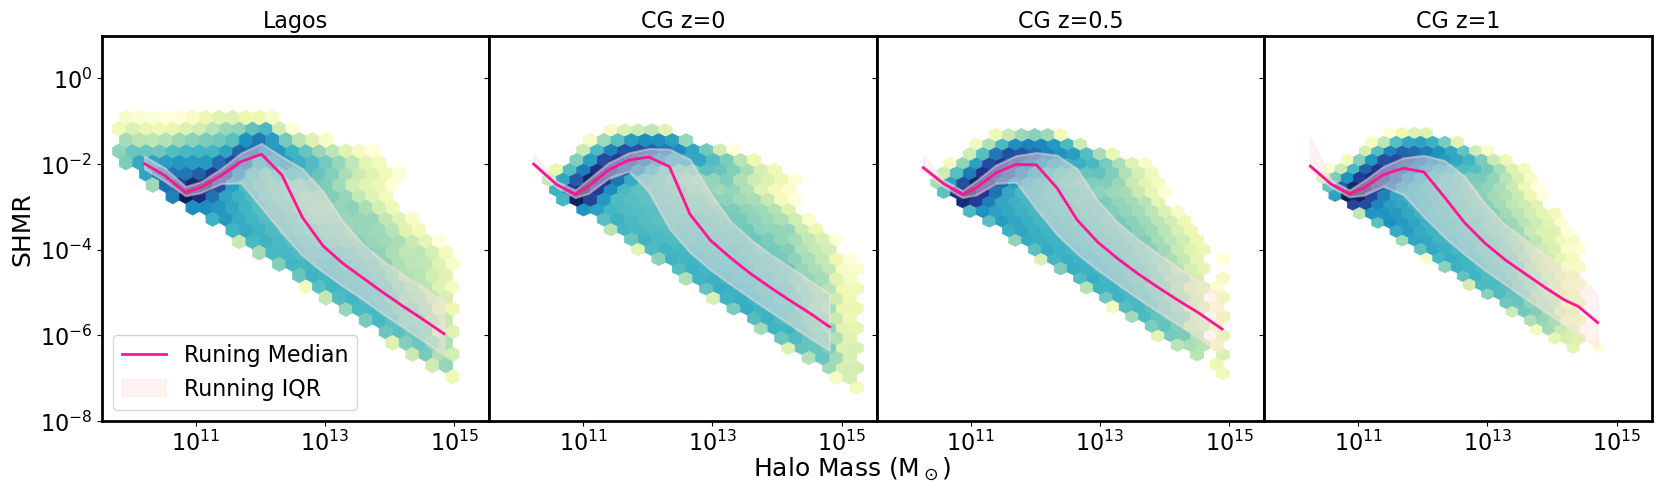

In [23]:
########################################
# SHMR vs. Halo Mass
########################################

datasets = [("Lagos", shark_csv_lagos),
            ("CG z=0", shark_csv),
            ("CG z=0.5", shark_csv_z05),
            ("CG z=1", shark_csv_z1)]

SHMR_threshold = 10**-9

# Create a 1x4 grid of subplots
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

# Set a shared x and y-axis range
y_min = 10**-8
y_max = 10
x_min = 3.5*10**9
x_max = 3.5*10**15

# Apply this range and ticks to all subplots
for ax in axs:
    ax.set_ylim([y_min, y_max])
    ax.set_xlim([x_min, x_max])
    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())  # Use scalar format for readability

# Loop through each dataset and create a plot
for i, (title, data) in enumerate(datasets):

    SHMR = data['Mstar_all'] / data['Mhalo_host']
    SHMR = np.where(SHMR < SHMR_threshold, SHMR_threshold, SHMR)
    
    # Calculate min and max log values of Mhalo_host
    lowLog = math.log10(data['Mhalo_host'].min())
    highLog = math.log10(data['Mhalo_host'].max())

    # Round to the nearest whole number for log binning
    lowLog = round(lowLog, 0)
    highLog = round(highLog, 0)

    # Create log bins
    num_bins = 16
    logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

    # MEDIAN for y-values
    result = binned_statistic(data['Mhalo_host'], SHMR, statistic='median', bins=logBins)
    bin_medians = result.statistic

    # Calculate xVals by finding the median Mhalo_host value within each bin
    xVals = []
    for j in range(len(logBins) - 1):
        # Filter data points within the current bin
        bin_data = data['Mhalo_host'][(data['Mhalo_host'] >= logBins[j]) & (data['Mhalo_host'] < logBins[j+1])]
        if len(bin_data) > 0:
            # Append the median of Mhalo_host values in the bin to xVals
            xVals.append(np.median(bin_data))
        else:
            # If no data points in the bin, append NaN or skip
            xVals.append(np.nan)

    # Convert xVals to a numpy array and remove NaN values (if necessary)
    xVals = np.array(xVals)
    valid_bins = ~np.isnan(xVals)
    xVals = xVals[valid_bins]
    bin_medians = bin_medians[valid_bins]

    # PERCENTILES
    # 25th percentile
    percentile_25 = binned_statistic(data['Mhalo_host'], SHMR, statistic=lambda values: np.percentile(values, 25), bins=logBins)
    p25 = percentile_25.statistic[valid_bins]
    # 75th percentile
    percentile_75 = binned_statistic(data['Mhalo_host'], SHMR, statistic=lambda values: np.percentile(values, 75), bins=logBins)
    p75 = percentile_75.statistic[valid_bins]

    # Plot on the current subplot
    axs[i].hexbin(data['Mhalo_host'], SHMR, gridsize=25, xscale='log', yscale='log',
                       reduce_C_function=np.sum, mincnt=50, bins='log', linewidth=0.5, cmap='YlGnBu')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_xlim([x_min, x_max])
    axs[i].set_ylim([y_min, y_max])

    # Bin plotting
    axs[i].plot(xVals, bin_medians, linewidth=2, color='deeppink', linestyle='-', label='Runing Median')
    axs[i].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.45, linewidth=1.5, label='Running IQR')

    # Set titles and remove y-axis labels for intermediate plots
    axs[i].set_title(f'{title}', fontsize=16)

# Add a single x-axis and y-axis label
fig.text(0.5, 0,r'Halo Mass (M$_\odot$)', ha='center', fontsize=18)
axs[0].set_ylabel('SHMR', fontsize=18)

axs[0].legend(loc='lower left', fontsize=16)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed



plt.show()

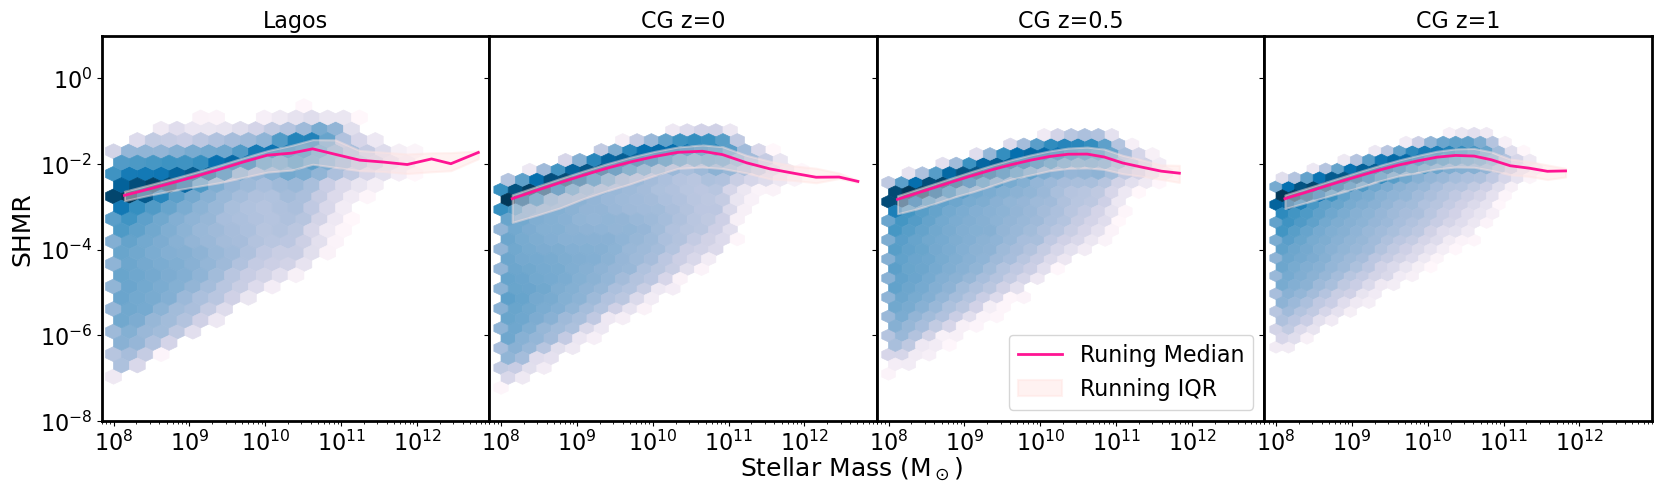

In [24]:
########################################
# SHMR vs. Stellar Mass
########################################

datasets = [("Lagos", shark_csv_lagos),
            ("CG z=0", shark_csv),
            ("CG z=0.5", shark_csv_z05),
            ("CG z=1", shark_csv_z1)]

SHMR_threshold = 10**-9

# Create a 1x4 grid of subplots
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

# Set a shared x and y-axis range
y_min = 10**-8
y_max = 10
x_min = 7*10**7
x_max = 9*10**12

# Apply this range and ticks to all subplots
for ax in axs:
    ax.set_ylim([y_min, y_max])
    ax.set_xlim([x_min, x_max])
    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())  # Use scalar format for readability

# Loop through each dataset and create a plot
for i, (title, data) in enumerate(datasets):

    SHMR = data['Mstar_all'] / data['Mhalo_host']
    SHMR = np.where(SHMR < SHMR_threshold, SHMR_threshold, SHMR)
    
    # Calculate min and max log values of Mstar_all
    lowLog = math.log10(data['Mstar_all'].min())
    highLog = math.log10(data['Mstar_all'].max())

    # Round to the nearest whole number for log binning
    lowLog = round(lowLog, 0)
    highLog = round(highLog, 0)

    # Create log bins
    num_bins = 16
    logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

    # MEDIAN for y-values
    result = binned_statistic(data['Mstar_all'], SHMR, statistic='median', bins=logBins)
    bin_medians = result.statistic

    # Calculate xVals by finding the median Mstar_all value within each bin
    xVals = []
    for j in range(len(logBins) - 1):
        # Filter data points within the current bin
        bin_data = data['Mstar_all'][(data['Mstar_all'] >= logBins[j]) & (data['Mstar_all'] < logBins[j+1])]
        if len(bin_data) > 0:
            # Append the median of Mstar_all values in the bin to xVals
            xVals.append(np.median(bin_data))
        else:
            # If no data points in the bin, append NaN or skip
            xVals.append(np.nan)

    # Convert xVals to a numpy array and remove NaN values (if necessary)
    xVals = np.array(xVals)
    valid_bins = ~np.isnan(xVals)
    xVals = xVals[valid_bins]
    bin_medians = bin_medians[valid_bins]

    # PERCENTILES
    # 25th percentile
    percentile_25 = binned_statistic(data['Mstar_all'], SHMR, statistic=lambda values: np.percentile(values, 25), bins=logBins)
    p25 = percentile_25.statistic[valid_bins]
    # 75th percentile
    percentile_75 = binned_statistic(data['Mstar_all'], SHMR, statistic=lambda values: np.percentile(values, 75), bins=logBins)
    p75 = percentile_75.statistic[valid_bins]

    # Plot on the current subplot
    axs[i].hexbin(data['Mstar_all'], SHMR, gridsize=25, xscale='log', yscale='log',
                       reduce_C_function=np.sum, mincnt=50, bins='log', linewidth=0.5, cmap='PuBu')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_xlim([x_min, x_max])
    axs[i].set_ylim([y_min, y_max])

    # Bin plotting
    axs[i].plot(xVals, bin_medians, linewidth=2, color='deeppink', linestyle='-', label='Runing Median')
    axs[i].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.45, linewidth=1.5, label='Running IQR')

    # Set titles and remove y-axis labels for intermediate plots
    axs[i].set_title(f'{title}', fontsize=16)

# Add a single x-axis and y-axis label
fig.text(0.5, 0,r'Stellar Mass (M$_\odot$)', ha='center', fontsize=18)
axs[0].set_ylabel('SHMR', fontsize=18)

axs[2].legend(loc='lower right', fontsize=16)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show()

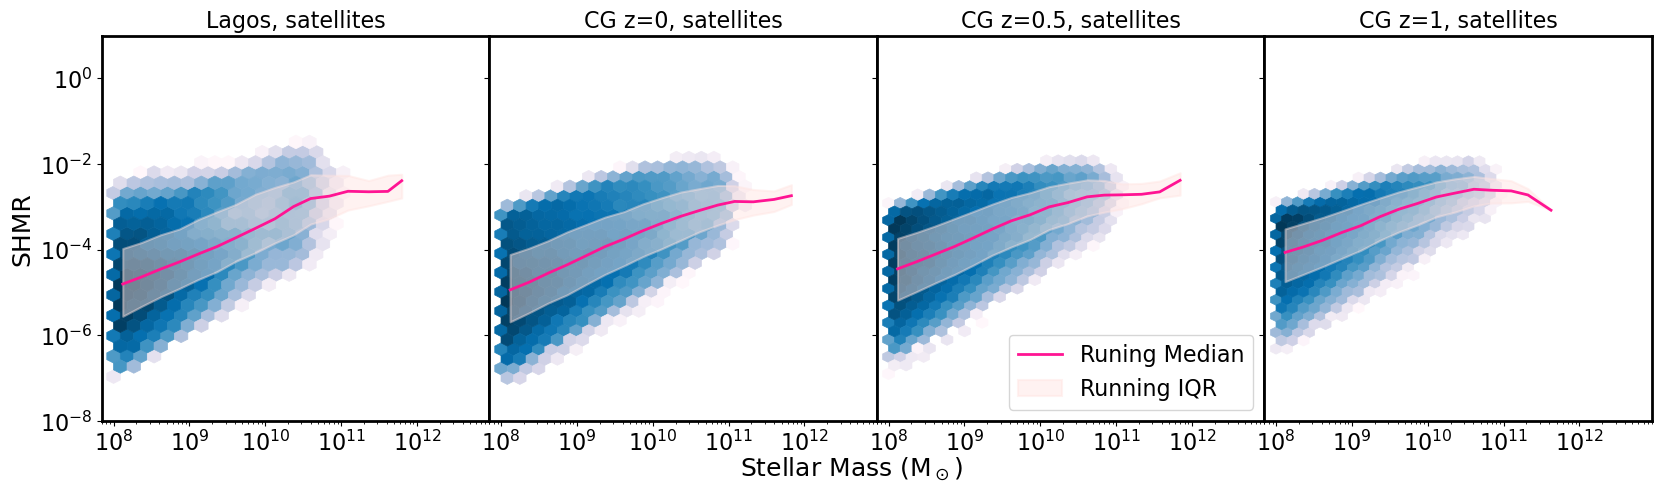

In [25]:
########################################
# SHMR vs. Stellar Mass - Satellites
########################################

# List of datasets for easy iteration
datasets = [("Lagos, satellites", shark_csv_satellites_lagos),
            ("CG z=0, satellites", shark_csv_satellites), 
            ("CG z=0.5, satellites", shark_csv_satellites_z05), 
            ("CG z=1, satellites", shark_csv_satellites_z1)]

SHMR_threshold = 10**-9

# Create a 1x4 grid of subplots
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

# Set a shared x and y-axis range
y_min = 10**-8
y_max = 10
x_min = 7*10**7
x_max = 9*10**12

# Apply this range and ticks to all subplots
for ax in axs:
    ax.set_ylim([y_min, y_max])
    ax.set_xlim([x_min, x_max])
    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())  # Use scalar format for readability

# Loop through each dataset and create a plot
for i, (title, data) in enumerate(datasets):

    SHMR = data['Mstar_all'] / data['Mhalo_host']
    SHMR = np.where(SHMR < SHMR_threshold, SHMR_threshold, SHMR)
    
    # Calculate min and max log values of Mstar_all
    lowLog = math.log10(data['Mstar_all'].min())
    highLog = math.log10(data['Mstar_all'].max())

    # Round to the nearest whole number for log binning
    lowLog = round(lowLog, 0)
    highLog = round(highLog, 0)

    # Create log bins
    num_bins = 16
    logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

    # MEDIAN for y-values
    result = binned_statistic(data['Mstar_all'], SHMR, statistic='median', bins=logBins)
    bin_medians = result.statistic

    # Calculate xVals by finding the median Mstar_all value within each bin
    xVals = []
    for j in range(len(logBins) - 1):
        # Filter data points within the current bin
        bin_data = data['Mstar_all'][(data['Mstar_all'] >= logBins[j]) & (data['Mstar_all'] < logBins[j+1])]
        if len(bin_data) > 0:
            # Append the median of Mstar_all values in the bin to xVals
            xVals.append(np.median(bin_data))
        else:
            # If no data points in the bin, append NaN or skip
            xVals.append(np.nan)

    # Convert xVals to a numpy array and remove NaN values (if necessary)
    xVals = np.array(xVals)
    valid_bins = ~np.isnan(xVals)
    xVals = xVals[valid_bins]
    bin_medians = bin_medians[valid_bins]

    # PERCENTILES
    # 25th percentile
    percentile_25 = binned_statistic(data['Mstar_all'], SHMR, statistic=lambda values: np.percentile(values, 25), bins=logBins)
    p25 = percentile_25.statistic[valid_bins]
    # 75th percentile
    percentile_75 = binned_statistic(data['Mstar_all'], SHMR, statistic=lambda values: np.percentile(values, 75), bins=logBins)
    p75 = percentile_75.statistic[valid_bins]

    # Plot on the current subplot
    axs[i].hexbin(data['Mstar_all'], SHMR, gridsize=25, xscale='log', yscale='log',
                       reduce_C_function=np.sum, mincnt=50, bins='log', linewidth=0.5, cmap='PuBu')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_xlim([x_min, x_max])
    axs[i].set_ylim([y_min, y_max])

    # Bin plotting
    axs[i].plot(xVals, bin_medians, linewidth=2, color='deeppink', linestyle='-', label='Runing Median')
    axs[i].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.45, linewidth=1.5, label='Running IQR')

    # Set titles and remove y-axis labels for intermediate plots
    axs[i].set_title(f'{title}', fontsize=16)

# Add a single x-axis and y-axis label
fig.text(0.5, 0,r'Stellar Mass (M$_\odot$)', ha='center', fontsize=18)
axs[0].set_ylabel('SHMR', fontsize=18)

axs[2].legend(loc='lower right', fontsize=16)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show()

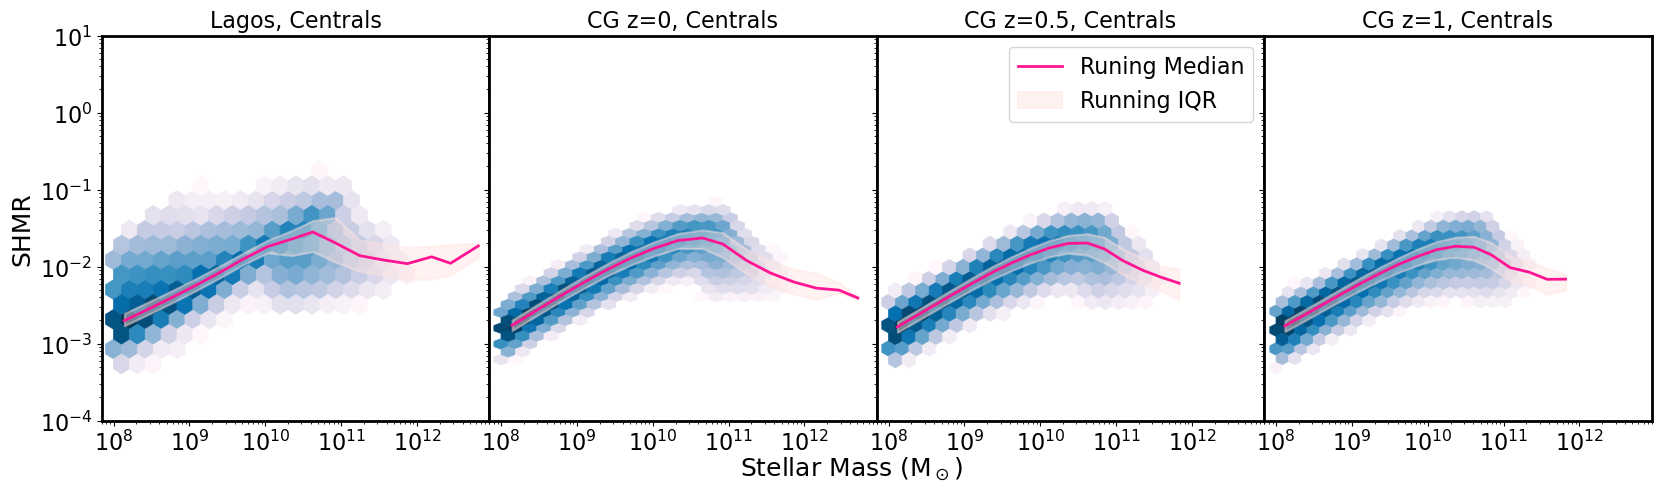

In [26]:
########################################
# SHMR vs. Stellar Mass - Centrals
########################################

# List of datasets for easy iteration
datasets = [("Lagos, Centrals", shark_csv_centrals_lagos),
            ("CG z=0, Centrals", shark_csv_centrals), 
            ("CG z=0.5, Centrals", shark_csv_centrals_z05), 
            ("CG z=1, Centrals", shark_csv_centrals_z1)]

SHMR_threshold = 10**-5

# Create a 1x4 grid of subplots
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

# Set a shared x and y-axis range
y_min = 10**-4
y_max = 10
x_min = 7*10**7
x_max = 9*10**12

# Apply this range and ticks to all subplots
for ax in axs:
    ax.set_ylim([y_min, y_max])
    ax.set_xlim([x_min, x_max])
    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())  # Use scalar format for readability

# Loop through each dataset and create a plot
for i, (title, data) in enumerate(datasets):

    SHMR = data['Mstar_all'] / data['Mhalo_host']
    SHMR = np.where(SHMR < SHMR_threshold, SHMR_threshold, SHMR)
    
    # Calculate min and max log values of Mstar_all
    lowLog = math.log10(data['Mstar_all'].min())
    highLog = math.log10(data['Mstar_all'].max())

    # Round to the nearest whole number for log binning
    lowLog = round(lowLog, 0)
    highLog = round(highLog, 0)

    # Create log bins
    num_bins = 16
    logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

    # MEDIAN for y-values
    result = binned_statistic(data['Mstar_all'], SHMR, statistic='median', bins=logBins)
    bin_medians = result.statistic

    # Calculate xVals by finding the median Mstar_all value within each bin
    xVals = []
    for j in range(len(logBins) - 1):
        # Filter data points within the current bin
        bin_data = data['Mstar_all'][(data['Mstar_all'] >= logBins[j]) & (data['Mstar_all'] < logBins[j+1])]
        if len(bin_data) > 0:
            # Append the median of Mstar_all values in the bin to xVals
            xVals.append(np.median(bin_data))
        else:
            # If no data points in the bin, append NaN or skip
            xVals.append(np.nan)

    # Convert xVals to a numpy array and remove NaN values (if necessary)
    xVals = np.array(xVals)
    valid_bins = ~np.isnan(xVals)
    xVals = xVals[valid_bins]
    bin_medians = bin_medians[valid_bins]

    # PERCENTILES
    # 25th percentile
    percentile_25 = binned_statistic(data['Mstar_all'], SHMR, statistic=lambda values: np.percentile(values, 25), bins=logBins)
    p25 = percentile_25.statistic[valid_bins]
    # 75th percentile
    percentile_75 = binned_statistic(data['Mstar_all'], SHMR, statistic=lambda values: np.percentile(values, 75), bins=logBins)
    p75 = percentile_75.statistic[valid_bins]

    # Plot on the current subplot
    axs[i].hexbin(data['Mstar_all'], SHMR, gridsize=25, xscale='log', yscale='log',
                       reduce_C_function=np.sum, mincnt=50, bins='log', linewidth=0.5, cmap='PuBu')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_xlim([x_min, x_max])
    axs[i].set_ylim([y_min, y_max])

    # Bin plotting
    axs[i].plot(xVals, bin_medians, linewidth=2, color='deeppink', linestyle='-', label='Runing Median')
    axs[i].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.45, linewidth=1.5, label='Running IQR')

    # Set titles and remove y-axis labels for intermediate plots
    axs[i].set_title(f'{title}', fontsize=16)

# Add a single x-axis and y-axis label
fig.text(0.5, 0,r'Stellar Mass (M$_\odot$)', ha='center', fontsize=18)
axs[0].set_ylabel('SHMR', fontsize=18)

axs[2].legend(loc='upper right', fontsize=16)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show()

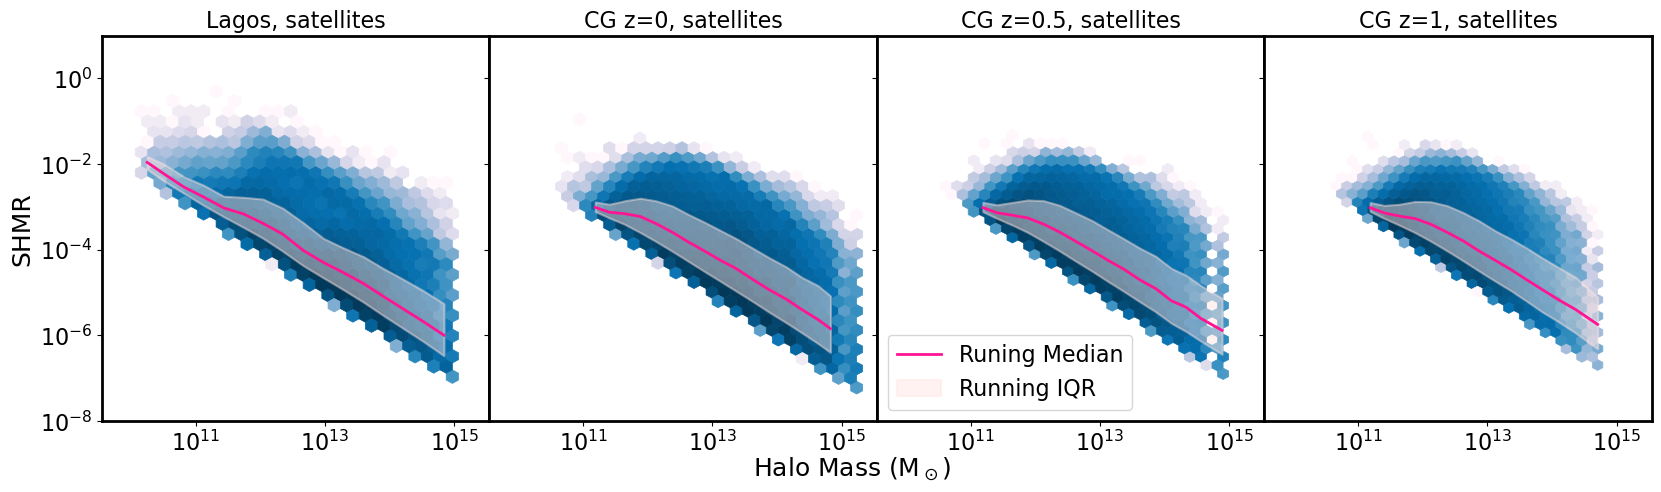

In [27]:
########################################
# SHMR vs. Halo Mass - SATELLITES
########################################

# List of datasets for easy iteration
datasets = [("Lagos, satellites", shark_csv_satellites_lagos),
            ("CG z=0, satellites", shark_csv_satellites), 
            ("CG z=0.5, satellites", shark_csv_satellites_z05), 
            ("CG z=1, satellites", shark_csv_satellites_z1)]

SHMR_threshold = 10**-9

# Create a 1x4 grid of subplots
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

# Set a shared x and y-axis range
y_min = 10**-8
y_max = 10
x_min = 3.5*10**9
x_max = 3.5*10**15

# Apply this range and ticks to all subplots
for ax in axs:
    ax.set_ylim([y_min, y_max])
    ax.set_xlim([x_min, x_max])
    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())  # Use scalar format for readability

# Loop through each dataset and create a plot
for i, (title, data) in enumerate(datasets):

    SHMR = data['Mstar_all'] / data['Mhalo_host']
    SHMR = np.where(SHMR < SHMR_threshold, SHMR_threshold, SHMR)
    
    # Calculate min and max log values of Mhalo_host
    lowLog = math.log10(data['Mhalo_host'].min())
    highLog = math.log10(data['Mhalo_host'].max())

    # Round to the nearest whole number for log binning
    lowLog = round(lowLog, 0)
    highLog = round(highLog, 0)

    # Create log bins
    num_bins = 16
    logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

    # MEDIAN for y-values
    result = binned_statistic(data['Mhalo_host'], SHMR, statistic='median', bins=logBins)
    bin_medians = result.statistic

    # Calculate xVals by finding the median Mhalo_host value within each bin
    xVals = []
    for j in range(len(logBins) - 1):
        # Filter data points within the current bin
        bin_data = data['Mhalo_host'][(data['Mhalo_host'] >= logBins[j]) & (data['Mhalo_host'] < logBins[j+1])]
        if len(bin_data) > 0:
            # Append the median of Mhalo_host values in the bin to xVals
            xVals.append(np.median(bin_data))
        else:
            # If no data points in the bin, append NaN or skip
            xVals.append(np.nan)

    # Convert xVals to a numpy array and remove NaN values (if necessary)
    xVals = np.array(xVals)
    valid_bins = ~np.isnan(xVals)
    xVals = xVals[valid_bins]
    bin_medians = bin_medians[valid_bins]

    # PERCENTILES
    # 25th percentile
    percentile_25 = binned_statistic(data['Mhalo_host'], SHMR, statistic=lambda values: np.percentile(values, 25), bins=logBins)
    p25 = percentile_25.statistic[valid_bins]
    # 75th percentile
    percentile_75 = binned_statistic(data['Mhalo_host'], SHMR, statistic=lambda values: np.percentile(values, 75), bins=logBins)
    p75 = percentile_75.statistic[valid_bins]

    # Plot on the current subplot
    axs[i].hexbin(data['Mhalo_host'], SHMR, gridsize=25, xscale='log', yscale='log',
                       reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0.5, cmap='PuBu')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_xlim([x_min, x_max])
    axs[i].set_ylim([y_min, y_max])

    # Bin plotting
    axs[i].plot(xVals, bin_medians, linewidth=2, color='deeppink', linestyle='-', label='Runing Median')
    axs[i].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.45, linewidth=1.5, label='Running IQR')
    
    # Set titles and remove y-axis labels for intermediate plots
    axs[i].set_title(f'{title}', fontsize=16)

# Add a single x-axis and y-axis label
fig.text(0.5, 0,r'Halo Mass (M$_\odot$)', ha='center', fontsize=18)
axs[0].set_ylabel('SHMR', fontsize=18)

axs[2].legend(loc='lower left', fontsize=16)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

plt.show()

bin medians Lagos, Centrals [0.01013983 0.0053878  0.0021602  0.00285382 0.00578228 0.0141957
 0.02694881 0.01515239 0.01142444 0.00951415 0.00859169 0.00746539
 0.00663614 0.00579824 0.0046551  0.00336142]
bin medians CG z=0, Centrals [0.00996608 0.00332604 0.00194005 0.00299674 0.00749088 0.01395771
 0.01949971 0.02209753 0.01686755 0.0118798  0.00880006 0.00681433
 0.00533463 0.00425703 0.00372359 0.00278835]
bin medians CG z=0.5, Centrals [0.00820036 0.00344727 0.00193655 0.00274928 0.00661907 0.01221271
 0.01649686 0.01781997 0.01387142 0.00967953 0.00737808 0.00568861
 0.00438318 0.00339239 0.00281058 0.00220751]
bin medians CG z=1, Centrals [0.00891315 0.00333286 0.00200623 0.00274809 0.00621933 0.01108746
 0.01493602 0.01477525 0.01173955 0.00826205 0.00628601 0.0051207
 0.00375223 0.00294251 0.00207759 0.00237588]


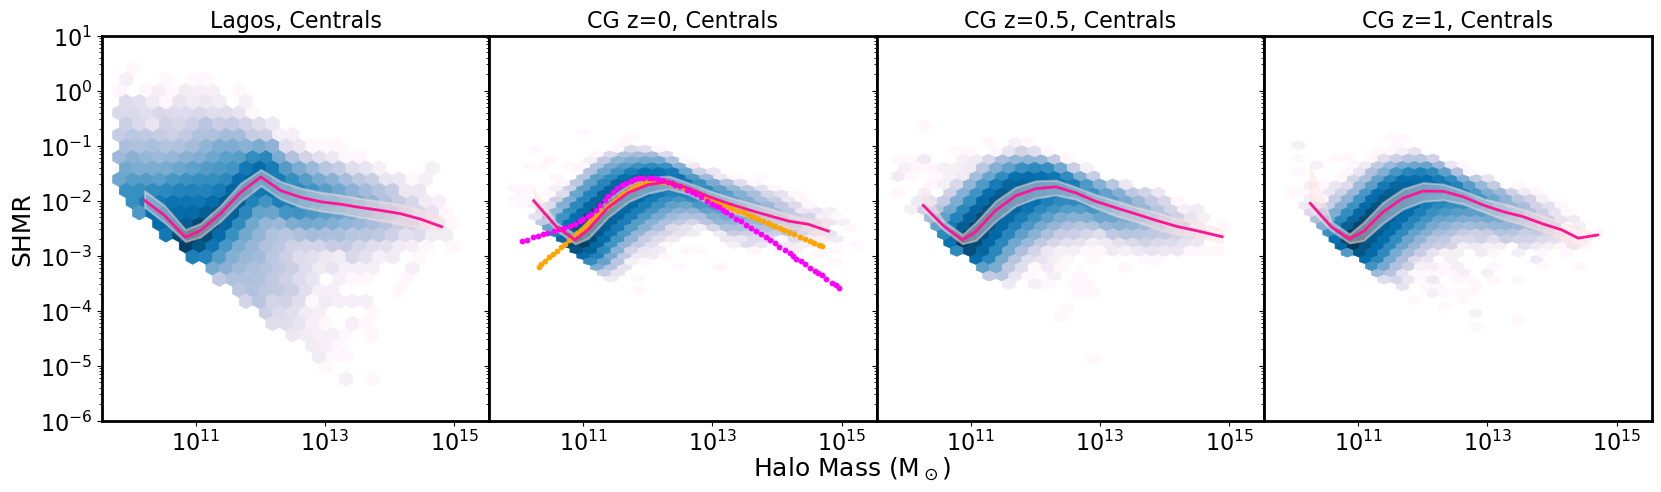

In [28]:
########################################
# SHMR vs. Halo Mass - CENTRALS
########################################

# List of datasets for easy iteration
datasets = [("Lagos, Centrals", shark_csv_centrals_lagos),
            ("CG z=0, Centrals", shark_csv_centrals), 
            ("CG z=0.5, Centrals", shark_csv_centrals_z05), 
            ("CG z=1, Centrals", shark_csv_centrals_z1)]

SHMR_threshold = 10**-7

# Create a 1x4 grid of subplots
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.subplots_adjust(wspace=0)

# Set a shared x and y-axis range
y_min = 10**-6
y_max = 10
x_min = 3.5*10**9
x_max = 3.5*10**15

# Apply this range and ticks to all subplots
for ax in axs:
    ax.set_ylim([y_min, y_max])
    ax.set_xlim([x_min, x_max])
    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())  # Use scalar format for readability

# Loop through each dataset and create a plot
for i, (title, data) in enumerate(datasets):

    SHMR = data['Mstar_all'] / data['Mhalo_host']
    SHMR = np.where(SHMR < SHMR_threshold, SHMR_threshold, SHMR)
    
    # Calculate min and max log values of Mhalo_host
    lowLog = math.log10(data['Mhalo_host'].min())
    highLog = math.log10(data['Mhalo_host'].max())

    # Round to the nearest whole number for log binning
    lowLog = round(lowLog, 0)
    highLog = round(highLog, 0)

    # Create log bins
    num_bins = 16
    logBins = np.logspace(lowLog, highLog, num=num_bins + 1)

    # MEDIAN for y-values
    result = binned_statistic(data['Mhalo_host'], SHMR, statistic='median', bins=logBins)
    bin_medians = result.statistic

    # Calculate xVals by finding the median Mhalo_host value within each bin
    xVals = []
    for j in range(len(logBins) - 1):
        # Filter data points within the current bin
        bin_data = data['Mhalo_host'][(data['Mhalo_host'] >= logBins[j]) & (data['Mhalo_host'] < logBins[j+1])]
        if len(bin_data) > 0:
            # Append the median of Mhalo_host values in the bin to xVals
            xVals.append(np.median(bin_data))
        else:
            # If no data points in the bin, append NaN or skip
            xVals.append(np.nan)

    # Convert xVals to a numpy array and remove NaN values (if necessary)
    xVals = np.array(xVals)
    valid_bins = ~np.isnan(xVals)
    xVals = xVals[valid_bins]
    bin_medians = bin_medians[valid_bins]

    print(f'bin medians {title}', bin_medians)

    # PERCENTILES
    # 25th percentile
    percentile_25 = binned_statistic(data['Mhalo_host'], SHMR, statistic=lambda values: np.percentile(values, 25), bins=logBins)
    p25 = percentile_25.statistic[valid_bins]
    # 75th percentile
    percentile_75 = binned_statistic(data['Mhalo_host'], SHMR, statistic=lambda values: np.percentile(values, 75), bins=logBins)
    p75 = percentile_75.statistic[valid_bins]

    # Plot on the current subplot
    axs[i].hexbin(data['Mhalo_host'], SHMR, gridsize=25, xscale='log', yscale='log',
                       reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0.5, cmap='PuBu')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_xlim([x_min, x_max])
    axs[i].set_ylim([y_min, y_max])

    # Bin plotting
    axs[i].plot(xVals, bin_medians, linewidth=2, color='deeppink', linestyle='-', label='Runing Median')
    axs[i].fill_between(xVals, p25, p75, color='mistyrose', alpha=0.45, linewidth=1.5, label='Running IQR')

    # Set titles and remove y-axis labels for intermediate plots
    axs[i].set_title(f'{title}', fontsize=16)

# Add a single x-axis and y-axis label
fig.text(0.5, 0,r'Halo Mass (M$_\odot$)', ha='center', fontsize=18)
axs[0].set_ylabel('SHMR', fontsize=18)

for ax in axs:
    # Set the border (spine) width
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # adjust the value as needed

    # Set the tick label sizes
    ax.tick_params(axis='both', labelsize=16)  # adjust the value as needed

axs[1].scatter(SHMRline["Column1"], SHMRline["Column2"], color='orange', s=10, label='Behroozi 2019') #BEHROOZI 2019
axs[1].scatter(SHMRline2["Column1"], SHMRline2["Column2"], color='magenta', s=10, label='Behroozi 2013') #BEHROOZI 2013

plt.show()

In [29]:
# I suspect it will take a number of cells to calculate the residuals to the running median of SHMR w.r.t. halo mass to centrals only.
# That is a number of dimensions of data. So, lets start with the basic.

# Running into issues trying to brute force it all at once. Rather, lets take it slow again, and do what we did in dexplots
# ie. make a new field which is residual to central for all four datasets.

# I need to loop this over the 4 datasets

datasets = [("CG z=0, Centrals", shark_csv_centrals), 
            ("CG z=0.5, Centrals", shark_csv_centrals_z05), 
            ("CG z=1, Centrals", shark_csv_centrals_z1), 
            ("Lagos, Centrals", shark_csv_centrals_lagos)]

SHMR_threshold = 10**-4

# Define log binning (same for all datasets)
lowLog_expected = 10  # log10(10^10)
highLog_expected = 15  # log10(10^15)
num_bins = 16
logBins = np.logspace(lowLog_expected, highLog_expected, num=num_bins + 1)

SHMR_meds = {}

# Loop over datasets
for title, data in datasets:
    # Compute SHMR for centrals and thresholding
    SHMR_centrals = data['Mstar_all'] / data['Mhalo_host']
    SHMR_centrals = np.where(SHMR_centrals < SHMR_threshold, SHMR_threshold, SHMR_centrals)

    # Verify dataset's log bounds
    lowLog = round(math.log10(data['Mhalo_host'].min()), 0)
    highLog = round(math.log10(data['Mhalo_host'].max()), 0)

    if lowLog != lowLog_expected or highLog != highLog_expected:
        raise ValueError(f"{title}: Expected log bounds ({lowLog_expected}, {highLog_expected}) "
                         f"but got ({lowLog}, {highLog}). Check your dataset.")

    # Compute median SHMR for centrals in each bin
    result = binned_statistic(
        data['Mhalo_host'],
        SHMR_centrals,
        statistic='median',
        bins=logBins
    )

    # Store bin medians separately for each dataset
    SHMR_meds[title] = result.statistic
    #print(SHMR_meds[title])
    
    # Print median SHMR values
    #print(f"Median SHMR values for centrals in each bin within {title}:")
    #print(bin_medians)
    #print(f"Log bin boundaries within {title}:")
    #print(logBins)
    #print('# of bins:', len(logBins))

In [30]:
#print(SHMR_meds['CG z=0.5, Centrals'])

In [31]:
# Second bin, loop through the standard datasets (not central or elliptical) and create an SHMR field

SHMR_threshold = 10**-4

datasets = [("CG z=0", shark_csv), 
            ("CG z=0.5", shark_csv_z05), 
            ("CG z=1", shark_csv_z1), 
            ("Lagos", shark_csv_lagos)]

for i, (title, data) in enumerate(datasets):

    SHMR = data['Mstar_all'] / data['Mhalo_host']
    SHMR = np.where(SHMR < SHMR_threshold, SHMR_threshold, SHMR)

    #print(len(SHMR))

    data['SHMR'] = SHMR

    print(f"Added SHMR column to {title}")

Added SHMR column to CG z=0
Added SHMR column to CG z=0.5
Added SHMR column to CG z=1
Added SHMR column to Lagos


In [32]:
#print(shark_csv_z05.head)

In [33]:
np.shape(shark_csv_lagos)

(928625, 33)